### Authorship
@author: Alexandre Pereira Santos <br>
alexandre.santos(at)lmu.de<br>
- uses OSMNx, pandas, geopandas, rasterio
- may include content from ChatGPT or GitHub Copilot

### Features
Calibrates the TI-City model parameters between two know time-steps.


### Prerequisites
- AOI vector file (i.e., shapefile or geopackage)
- Raster reference file with the same extent as the AOI

## Roadmap:

1. Import areal units (GADM2) for the AOIs
2. Calculate key population distribution indicators
   1. Total GDP (PPP)
   2. Population (total and density) 
   3. Total urbanised area
   4. HDI per admin level 2 unit
3. Estimate the proportions of each socioeconomic bracket in the urban parts of each areal unit
4. Import the model calibration results and check calibration accuracy

# imports

In [1]:
# utils
import os
from pathlib import Path
#import fnmatch
#import shutil
#import tempfile
#import logging

# maths
import numpy as np
#import random 
import matplotlib.pyplot as plt
#import matplotlib.colors as mcolors
#import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter, distance_transform_edt
#import skimage.graph
from skimage.graph import route_through_array

# GIS
#from shapely.geometry.polygon import Polygon
#from shapely.geometry import MultiLineString, LineString, MultiPolygon, Point, MultiPoint, GeometryCollection
#import seaborn as sns
#import json
import pandas as pd
import geopandas as gpd
#import osmnx as ox

# raster stuff
import rasterio
from rasterio import features
from rasterio.warp import reproject, calculate_default_transform, Resampling
from rasterio.mask import mask
from rasterio.plot import show, show_hist, plotting_extent
from rasterio import plot
#from osgeo import gdal, osr    
#import ee
#import geemap
import rasterstats

from ti_city_00_raster_functions import *
from ti_city_00_raster_functions import majority_filter

# init

In [2]:
#  the 'case_city' variable defines the city we are working on. 
# APS: Need to update the code below to change it from MUM to the variable name

case_city = 'JAK' #MUM MAN JAK
drop_path = r'C:\\Sciebo\\05_GIS\\' # adjust this to match the path on your computer, e.g. 'D:\\Dropbox\\x\\PostDoc\\GIS' or 'C:\\Users\\x\\Dropbox\\x\\PostDoc\\GIS'
external_data_path = Path(r'C:\\Sciebo\\00_data') # adjust this to match the path on your computer, e.g. 'D:\\Dropbox\\x\\PostDoc\\00_data' or 'C:\\Users\\x\\Dropbox\\x\\PostDoc\\00_data'
## ascii150_arcgis_path = Path(r"D:\\Dropbox\\x\\PostDoc\ASCII_150m") deprecated, ignore

#input a vector and a raster file for each city
AOI_path = Path(f'{drop_path}\\{case_city}\\processed\\')
AOI_file = f'{case_city}_LIM_AOI_reference_150m_A.shp' # APS: updated AOI 01.08.2024

AOI_gdf = gpd.read_file(AOI_path / AOI_file) #.to_crs(epsg=4326)
AOI_gdf_4326 = AOI_gdf.to_crs(epsg=4326) 

ref_raster_path = Path(f'../data/processed/{case_city}_LIM_reference_AOI_150m.tif')
ref_raster_150_path = Path(f'../data/processed/{case_city}_LIM_reference_AOI_150m.tif')

raw_path = Path(f'\\{case_city}\\raw\\')
interim_path = Path(drop_path + f'{case_city}\\interim\\')
processed_path = Path(drop_path + f'{case_city}\\processed\\')
external_path = Path(drop_path + f'{case_city}\\external\\')
model_inputs_30m_path = Path(drop_path + f'{case_city}\\model_inputs\\TIFF_30m\\')
model_inputs_150m_path = Path(drop_path + f'{case_city}\\model_inputs\\TIFF_150m\\')
model_inputs_SLEUTH_150m_path = Path(drop_path + f'{case_city}\\model_inputs\\TIFF_SLEUTH_150m')
ascii150_path = Path(drop_path + f'\\{case_city}\\model_inputs\\ASCII_150m')
ascii150_SLEUTH_path = Path(drop_path + f'\\{case_city}\\model_inputs\\ASCII_SLEUTH_150m')
ti_city_ascii_path = Path(f'../model/{case_city}/data/in/')
ti_city_out_path = Path(f'../model/{case_city}/data/out/')
ref_raster_sleuth_path = model_inputs_SLEUTH_150m_path / (case_city + '_URB_SLEUTH_input_2022.tif' )

if case_city == 'MUM':
    gadm_var = 'NAME_3'
    calibration_years = [2015,2025]

if case_city == 'MAN':    
    gadm_var = 'NAME_2'
    calibration_years = [2015,2025]

if case_city == 'JAK':
    gadm_var = 'NAME_3'
    calibration_years = [2015,2025]

#%run ./ti_city_00_raster_functions.ipynb

# read the reference raster
with rasterio.open(ref_raster_path,'r') as src: # APS 20.08.2025 using the 150 m raster
    ref_raster = src
    ref_meta = src.meta
    ref_height, ref_width, ref_area = get_transform(ref_raster)

# suppress deprecation warnings
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [3]:
# print the AOI bound coordinates
bounds = AOI_gdf.total_bounds
# print the AOI bound coordinates
bounds = AOI_gdf.total_bounds
print("AOI bounds:")
print(f"| {'lon_min':<10} | {'lat_min':<10} |")
print(f"| {'lon_max':<10} | {'lat_max':<10} |")
print(f"| {bounds[0]:<10.4f} | {bounds[1]:<10.4f} |")
print(f"| {bounds[2]:<10.4f} | {bounds[3]:<10.4f} |")


AOI bounds:
| lon_min    | lat_min    |
| lon_max    | lat_max    |
| 639000.0000 | 9249000.0000 |
| 754800.0000 | 9351000.0000 |


# 0. data cleaning and preparation 
(probably only needed once per data set)

# 1. Import base data 

## 1.1 GDP

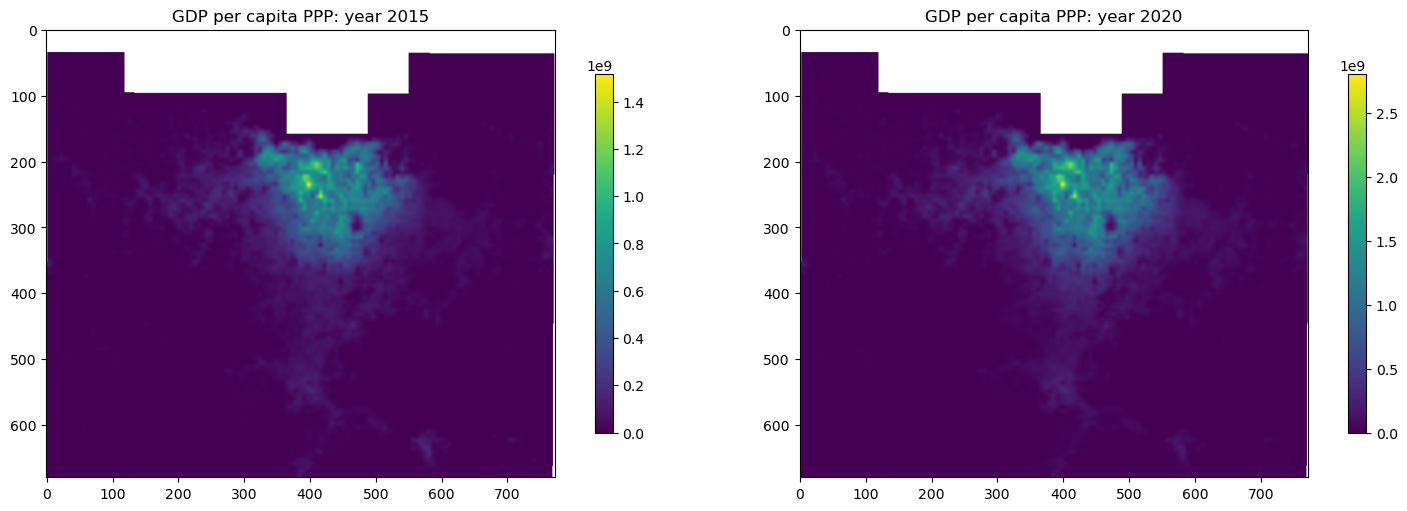

In [4]:
# load the GDP data from Kummu et al. (2025) for the years 2000 and 2020 (bands 3 and 7, respectively)
# Kummu M, Kosonen M, Masoumzadeh Sayyar S. Downscaled gridded global dataset for gross domestic product (GDP) per capita PPP over 1990–2022. Sci Data. 2025;12(1):178. doi:10.1038/s41597-025-04487-x
# Updated dataset: https://zenodo.org/records/18429133 (includes 2024 data)

''' Bands:
1 - 1990
2 - 1995
3 - 2000
4 - 2005
5 - 2010
6 - 2015
7 - 2020
8 - 2024'''


gdp_file = case_city + '_ECO_GDP_PPP_1990_2024_Kummu_etal.tif'
gdp_path = external_path / gdp_file
gdp_bands = [6,8] #band 6 = 2015, band 8 = 2024
with rasterio.open(gdp_path, 'r') as src:
    gdp_early = src.read(gdp_bands[0]) # read band 6 for the year 2015
    gdp_early_meta = src.meta.copy()
    gdp_late = src.read(gdp_bands[1]) # read band 8 for the year 2020
    gdp_late_meta = src.meta.copy()
    # clip the GDP data to the AOI
    gdp_early, _ = mask(src, AOI_gdf.geometry, crop=True, indexes=gdp_bands[0])
    gdp_late, _ = mask(src, AOI_gdf.geometry, crop=True, indexes=gdp_bands[1])
# plot the GDP data for the years 2015 and 2020 side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
im = axes[0].imshow(gdp_early.squeeze(), cmap='viridis')
axes[0].set_title(f'GDP per capita PPP: year 2015')
fig.colorbar(im, ax=axes[0], shrink=0.8)
im = axes[1].imshow(gdp_late.squeeze(), cmap='viridis')
axes[1].set_title(f'GDP per capita PPP: year 2020')
fig.colorbar(im, ax=axes[1], shrink=0.8)
plt.show()

In [5]:
# import the GADM3 shapefile with pre-calculated data, if it exists, and check the columns
gadmin3_GDP_file = case_city + '_ECO_GDP_PPP_admin3_stats_A.shp'
gadmin3_GDP_path = interim_path / gadmin3_GDP_file
if gadmin3_GDP_path.exists():
    gadmin3_GDP_gdf = gpd.read_file(gadmin3_GDP_path)
    #print(f'GADM3 shapefile with GDP data found. Columns: {gadmin3_GDP_gdf.columns.tolist()}')
    gadmin3_GDP_gdf.head()
else:
    print(f'**GADM3 shapefile with GDP data not found at {gadmin3_GDP_path}.\n Please run the code to calculate the GDP statistics per admin 3 unit and save it as a shapefile before proceeding.')

In [6]:
gadmin3_GDP_gdf.head()

,ADM3_EN,ADM3_PCODE,ADM2_EN,ADM2_PCODE,Shape_Leng,Shape_Area,mean_2000,min_2000,max_2000,std_2000,...,cells_0_25,cells_25th,cells_medi,cells_75th,cell_cou_1,cells_0__1,cells_25_1,cells_me_1,cells_75_1,geometry
0,Dramaga,ID3201060,Bogor,ID3201,41764.274838,2.560295e+07,8.931283e+06,1.310419e+06,25374336.0,7.085685e+06,...,0,631,725,404,1131,0,653,742,379,"POLYGON ((690340.922 9266867.007, 690319.857 9..."
1,Tanjung Priok,ID3175030,Kota Jakarta Utara,ID3175,34408.190734,2.243273e+07,1.900308e+08,2.183574e+07,285240608.0,5.171131e+07,...,0,0,0,994,994,0,0,0,994,"MULTIPOLYGON (((709230.77 9320652.394, 709230...."
2,Babelan,ID3216090,Bekasi,ID3216,64962.606224,6.596211e+07,9.075047e+06,5.905180e+01,80008672.0,1.536072e+07,...,165,1875,1159,787,2937,122,1764,1278,829,"POLYGON ((726616.911 9317178.419, 726626.763 9..."
3,Karang Tengah,ID3671012,Kota Tangerang,ID3671,18969.492864,9.849298e+06,5.394436e+07,1.933895e+07,99847840.0,1.732595e+07,...,0,0,0,437,437,0,0,0,437,"POLYGON ((690314.793 9313251.924, 690314.99 93..."
4,Ciledug,ID3671010,Kota Tangerang,ID3671,15279.927726,8.944131e+06,4.903508e+07,3.004989e+07,73889544.0,1.131158e+07,...,0,0,0,400,400,0,0,0,400,"POLYGON ((689186.943 9308629.595, 689149.261 9..."


## 1.2 HDI series

In [15]:
HDI_file_name = case_city + ' POP HDI Components_BPS.xlsx'
HDI_path = external_path / HDI_file_name
# read the HDI data from the Excel file
hdi_df = pd.read_excel(HDI_path,dtype={'ADM2_EN': str, 'EYE2015': 'float64', 'EYE2020': 'float64', 
                                       'EYE2025': 'float64', 'LEB2015': 'float64', 'LEB2020': 'float64', 
                                       'LEB2025': 'float64', 'AEP2015': 'float64', 'AEP2020': 'float64', 'AEP2025': 'float64',
                                       'Notes': str})
# drop rows with NaN values in the 'ADM2_EN' column
hdi_df = hdi_df.dropna(subset=['ADM2_EN'])
# round off all cells with numeric values to two digits
hdi_df = hdi_df.round({col: 2 for col in hdi_df.columns if hdi_df[col].dtype in ['float64']})

# check which rows have nan values in other columns, listing the 'ADMN_EN' values for those rows
nan_rows = hdi_df[hdi_df.drop(columns=['Notes']).isna().any(axis=1)].copy()
nan_rows['nan_columns'] = nan_rows.apply(
    lambda row: [col for col in row.index[row.isna()].tolist() if col != 'Notes'],
    axis=1
)
print(type(nan_rows))
print(nan_rows[['ADM2_EN', 'nan_columns']])


<class 'pandas.DataFrame'>
                 ADM2_EN                                        nan_columns
5             Bogor City                        [LEB2015, EYE2015, AEP2015]
6          Bogor Regency  [LEB2020, EYE2020, AEP2020, LEB2015, EYE2015, ...
7            Bekasi City                        [LEB2015, EYE2015, AEP2015]
9             Depok City                        [LEB2015, EYE2015, AEP2015]
10        Tangerang City                        [LEB2015, EYE2015, AEP2015]
11  South Tangerang City  [LEB2020, EYE2020, AEP2020, LEB2015, EYE2015, ...
12     Tangerang Regency  [LEB2020, EYE2020, AEP2020, LEB2015, EYE2015, ...


In [16]:
# estimate the missing components for the rows with missing values
# For Bogor City, Bekasi City, Depok City, and Tangerang City, South Tangerang City and Tangerang Regency, we have data for 2020 and 2025, but not for 2015
# Let's estimate the missing values for 2015 by calculating the average annual change between 2020 and 2025, and then applying that change to estimate the 2015 values. 
# We will do this for each of the HDI components: Life Expectancy, Education Index, and Income Index.
# create a copy of the original dataframe to store the estimated values
hdi_df_estimated = hdi_df.copy()
for index, row in nan_rows.iterrows():
    #print(f"Estimating missing values for {row.ADM2_EN} with missing columns: {row.nan_columns}")
    for col in row.nan_columns:
        #print(col, type(col))
        # the column names start with three letters indicating the component (EYE for education, LEB for life expectancy, AEP for income) followed by the year (2015, 2020, 2025)
        # let's iterate through each column to estimate the rate of change and then fill in the values for 2015
        prefix = col[:3]
        col_2015 = prefix + '2015'
        col_2020 = prefix + '2020'
        col_2024 = prefix + '2024'
        
        # let's check if we're iterating correctly through the missing columns for each city
        #print(hdi_df_estimated.loc[index, 'ADM2_EN'], prefix, col_2024, col_2020)

        componente_2024_2020_change = round((hdi_df_estimated.loc[index, col_2024] - hdi_df_estimated.loc[index, col_2020]) / 4,2)
        # calculate the HDI annual change as a baseline for the component estimate
        hdi_2024_2020_change = round((hdi_df_estimated.loc[index, 'HDI2024'] - hdi_df_estimated.loc[index, 'HDI2020']) / 4,2)
        hdi_2020_2015_change = round((hdi_df_estimated.loc[index, 'HDI2020'] - hdi_df_estimated.loc[index, 'HDI2015']) / 5,2)
        component_hdi_rate = round(100*(componente_2024_2020_change / hdi_2024_2020_change),2) if hdi_2024_2020_change != 0 else 0
        #print('the component annual change is:', componente_2024_2020_change, ', the HDI annual change is:', hdi_2024_2020_change, '(',component_hdi_rate,'%)')
        if componente_2024_2020_change is None or np.isnan(componente_2024_2020_change) or componente_2024_2020_change == 0:
            if (hdi_2024_2020_change is None or np.isnan(hdi_2024_2020_change) or (hdi_2024_2020_change == 0)):
                #print(f'-- {hdi_df_estimated.loc[index, "ADM２_EN"]}: the component annual change for {col} is not valid. Cannot estimate the ２０１５ value for {col}.')
                hdi_df_estimated.loc[index, col] = np.nan
                if pd.isna(hdi_df_estimated.loc[index, 'Notes']):
                    hdi_df_estimated.loc[index, 'Notes'] = f'{col} has **no** valid estimate'
                else:
                    hdi_df_estimated.loc[index, 'Notes'] = str(hdi_df_estimated.loc[index, 'Notes']) + f'; {col} has **no** valid estimate'
                #print(f'-- {hdi_df_estimated.loc[index, "ADM2_EN"]}: {prefix} **not valid** component annual change ({componente_2024_2020_change}), the HDI annual change is: {hdi_2024_2020_change}') #, the component/HDI change rate is: {component_hdi_rate}%.
            elif  ((np.isnan(hdi_df_estimated.loc[index, col_2020])) or (hdi_df_estimated.loc[index, col_2020] == 0)):
                # check if the component exists for 2024 instead and use the HDI annual change to estimate the 2020 and 2015 values
                if not (np.isnan(hdi_df_estimated.loc[index, col_2024]) or hdi_df_estimated.loc[index, col_2024] == 0):
                    hdi_df_estimated.loc[index, col_2020] = round(hdi_df_estimated.loc[index, col_2024] - (hdi_2024_2020_change * 5),2)
                    hdi_df_estimated.loc[index, col_2015] = round(hdi_df_estimated.loc[index, col_2020] - (hdi_2020_2015_change * 5),2)    
                    #print(f'-+ {hdi_df_estimated.loc[index, "ADM2_EN"]}: {prefix} missing 2020 value but valid 2024 value. Estimated 2020 value: {hdi_df_estimated.loc[index, col_2020]}, estimated 2015 value: {hdi_df_estimated.loc[index, col_2015]}')
                    if pd.isna(hdi_df_estimated.loc[index, 'Notes']):
                        hdi_df_estimated.loc[index, 'Notes'] = f'{col} estimate from HDI available years'
                    else:
                        hdi_df_estimated.loc[index, 'Notes'] = str(hdi_df_estimated.loc[index, 'Notes']) + f'; {col} estimate from HDI available years'
            else:                
                hdi_df_estimated.loc[index, col] = round(hdi_df_estimated.loc[index, col_2020] - (hdi_2024_2020_change * 5),2)
                if pd.isna(hdi_df_estimated.loc[index, 'Notes']):
                    hdi_df_estimated.loc[index, 'Notes'] = f'{col} estimate for 2020 & 2025 from HDI change'
                else:
                    hdi_df_estimated.loc[index, 'Notes'] = str(hdi_df_estimated.loc[index, 'Notes']) + f'; {col} estimate for 2020 & 2025 from HDI change'
                #print(f'-+ {hdi_df_estimated.loc[index, "ADM2_EN"]}: the component annual change for {col} is not valid but HDI is valid. Using HDI rate to estimate.')
                #print(f'-+ {hdi_df_estimated.loc[index, "ADM2_EN"]}: {prefix} valid HDI annual Change ({hdi_2024_2020_change}), estimated value: {hdi_df_estimated.loc[index, col]}')
        elif component_hdi_rate > 100:            
            hdi_df_estimated.loc[index, col] = round(hdi_df_estimated.loc[index, col_2020] - (hdi_2024_2020_change * 5),2)
            if pd.isna(hdi_df_estimated.loc[index, 'Notes']):
                    hdi_df_estimated.loc[index, 'Notes'] = f'{col} estimates from HDI available years'
            else:
                hdi_df_estimated.loc[index, 'Notes'] = str(hdi_df_estimated.loc[index, 'Notes']) + f'; {col} estimates from HDI available years'
            #print(f'- {hdi_df_estimated.loc[index, "ADM2_EN"]}: the component annual change is greater than the HDI annual change. Use HDI rate instead to estimate the component change.')
            #print(f'+{hdi_df_estimated.loc[index, "ADM2_EN"]}: {prefix} component annual change ({componente_2024_2020_change}) too large compared to HDI annual change ({hdi_2024_2020_change}), estimated value: {hdi_df_estimated.loc[index, col]}')
        
        else:            
            hdi_df_estimated.loc[index, col] = round(hdi_df_estimated.loc[index, col_2020] - (componente_2024_2020_change * 5),2)
            if pd.isna(hdi_df_estimated.loc[index, 'Notes']):
                hdi_df_estimated.loc[index, 'Notes'] = f'{col} estimate from components available years'
            else:
                hdi_df_estimated.loc[index, 'Notes'] = str(hdi_df_estimated.loc[index, 'Notes']) + f'; {col} estimate from components available years'
            #print(f'{hdi_df_estimated.loc[index, "ADM2_EN"]}: the {prefix} component annual change is valid.')
            #print(f'++{hdi_df_estimated.loc[index, "ADM2_EN"]}: valid component {prefix} annual change:', componente_2024_2020_change, ', estimated value: ', hdi_df_estimated.loc[index, col])

    # check the estimated values for the rows that had missing values in 2015
    #estimated_rows = hdi_df_estimated[hdi_df_estimated['EYE2015'].isna() == False]
#print(estimated_rows[['ADM2_EN', 'EYE2015', 'LEB2015', 'AEPC2015']])
hdi_df_estimated

,ADM2_EN,ADM2_BA,ADM2CODE,HDI2024,HDI2020,HDI2015,LEB2024,EYE2024,AEP2024,LEB2020,EYE2020,AEP2020,LEB2015,EYE2015,AEP2015,Notes
0,South Jakarta,Kota Jakarta Selatan,ID3171,88.51,85.40,83.37,76.23,13.94,25573.00,75.45,13.33,23575.00,73.81,13.09,22425.00,NaN
1,East Jakarta,Kota Jakarta Timur,ID3172,85.51,82.84,80.73,75.59,14.07,19193.00,74.82,13.86,17438.00,74.10,13.06,16455.00,NaN
2,Central Jakarta,Kota Jakarta Pusat,ID3173,84.45,82.22,79.69,76.57,13.31,18661.00,75.77,13.25,17179.00,73.70,12.51,16143.00,NaN
3,West Jakarta,Kota Jakarta Barat,ID3174,85.18,82.33,79.72,75.98,13.14,22119.00,75.52,12.80,20468.00,73.32,12.39,19006.00,NaN
4,North Jakarta,Kota Jakarta Utara,ID3175,83.12,81.04,78.30,75.17,12.70,20032.00,74.78,12.63,18437.00,72.91,11.89,17205.00,NaN
5,Bogor City,Kota Bogor,ID3271,79.15,77.11,73.65,76.25,13.69,13571.00,74.92,13.42,11716.00,73.27,13.07,11713.45,LEB2015 estimate from components available yea...
6,Bogor Regency,Bogor,ID3201,73.63,72.40,70.86,74.90,12.75,11563.00,73.35,11.20,11561.45,71.80,9.65,11559.90,LEB2020 estimate from HDI available years; EYE...
7,Bekasi City,Kota Bekasi,ID3275,83.55,81.50,79.63,76.14,14.14,16775.00,75.01,14.00,15776.00,73.61,13.80,15773.45,LEB2015 estimate from components available yea...
8,Bekasi Regency,Bekasi,ID3216,77.80,74.07,71.19,74.57,13.18,12500.00,73.68,13.09,11241.00,73.18,11.93,10323.00,NaN
9,Depok City,Kota Depok,ID3276,83.05,81.14,78.75,75.82,14.11,16640.00,74.80,13.92,15281.00,73.55,13.67,15278.60,LEB2015 estimate from components available yea...


City/regency list from HDI: ['Kota Jakarta Selatan', 'Kota Jakarta Timur', 'Kota Jakarta Pusat', 'Kota Jakarta Barat', 'Kota Jakarta Utara', 'Kota Bogor', 'Bogor', 'Kota Bekasi', 'Bekasi', 'Kota Depok', 'Kota Tangerang', 'Kota Tangerang Selatan', 'Tangerang']
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,

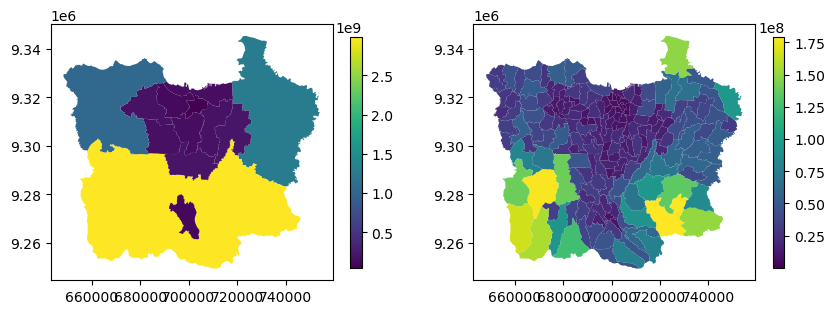

In [17]:
# import gadm level 3 shapefile for the AOI and join it with the HDI dataframe 
admin3_file_name = case_city + '_LIM_admin_boundaries_lvl3_OCHA_2025_A.shp'
col_list = ['ADM2_EN',  'Shape_Leng', 'Shape_Area','geometry']
dtype_dict = {'ADM2_EN': str, 'ADM2_PCODE': str, 'Shape_Leng': float, 'Shape_Area': float, 'geometry': 'geometry'}
admin3_gdf = gpd.read_file(external_path / admin3_file_name, columns=col_list, dtype = dtype_dict) #, columns=['ADM2_EN', 'ADM2_PCODE', 'Shape_Leng', 'Shape_Area','geometry']

# rename the 'ADM2_EN' column to 'ADM2_BA' to match the HDI dataframe
admin3_gdf = admin3_gdf.rename(columns={'ADM2_EN': 'ADM2_BA'})
# remove the lines that are not in the HDI dataframe based on the 'ADM2_BA' column, which is the common column between the two dataframes
index_list = hdi_df_estimated['ADM2_BA'].tolist()
print(f'City/regency list from HDI: {index_list}')
print(admin3_gdf.index.tolist())
admin3_gdf = admin3_gdf[admin3_gdf.ADM2_BA.isin(index_list)]

# dissolve the shapefile per the 'ADM2_BA' column (creating adm level 2 units)
admin2_gdf = admin3_gdf.dissolve(by='ADM2_BA', aggfunc='sum', as_index=True) #, as_index=True 
#print(admin2_gdf.columns)


# join the HDI dataframe with the shapefile based on the 'ADM2_BA' column in the HDI dataframe and the index of the shapefile
admin2_gdf = admin2_gdf.join(hdi_df_estimated.set_index('ADM2_BA'), how='left', on='ADM2_BA')

#re-order the columns to have 'ADM2_BA' as the first column, followed by 'ADM2_EN', and then the HDI components, with the  'Shape_Length','Shape_Area', 'geometry', and 'Notes' columns at the end
cols = admin2_gdf.columns.tolist()
#print(cols)
cols = [col for col in cols if col not in ['Shape_Leng', 'Shape_Area', 'geometry', 'Notes']] + ['Shape_Leng', 'Shape_Area', 'geometry', 'Notes']
admin2_gdf = admin2_gdf[cols]
print(f'GADM2 columns: {cols}')
# recalculate the area for the gadm level 2 units based on the geometry column and compare it with the original 'Shape_Area' column to check if they match
#admin2_gdf['calculated_area'] = admin2_gdf.geometry.area.round(2)
#admin2_gdf['area_difference'] = round(admin2_gdf['Shape_Area'] - admin2_gdf['calculated_area'], 2)
#admin2_gdf['area_difference_pc'] = round(100*(admin2_gdf['area_difference'] / admin2_gdf['Shape_Area']), 4)
#print(admin2_gdf[['Shape_Area', 'calculated_area', 'area_difference', 'area_difference_pc']])

fig, ax = plt.subplots(ncols = 2, figsize=(10, 10))
admin2_gdf.plot(
    'Shape_Area',
    ax=ax[0],
    legend=True,
    cmap='viridis',
    legend_kwds={'shrink': 0.3}
)
admin3_gdf.plot('Shape_Area', ax=ax[1], legend=True, cmap='viridis', legend_kwds={'shrink': 0.3})
plt.show()

In [18]:
# export new dataframe with estimated values to an Excel file
export_files = False
if export_files == True:
    output_file = interim_path / (case_city + '_POP_HDI_component_estimates.xlsx')
    dtype={'ADM2_EN': str, 'EYE2015': 'float64', 'EYE2020': 'float64', 
                                        'EYE2025': 'float64', 'LEB2015': 'float64', 'LEB2020': 'float64', 
                                        'LEB2025': 'float64', 'AEP2015': 'float64', 'AEP2020': 'float64', 'AEP2025': 'float64',
                                        'Notes': str}
    hdi_df_estimated.to_excel(output_file, index=False)

In [19]:
# export the adm level 2 dataframe as a shapefile
export_files = False
if export_files == True:
    output_shapefile = interim_path / (case_city + '_POP_HDI_component_estimates_ADMlvl2_A.shp')
    admin2_gdf.to_file(output_shapefile)

## 1.3 Population

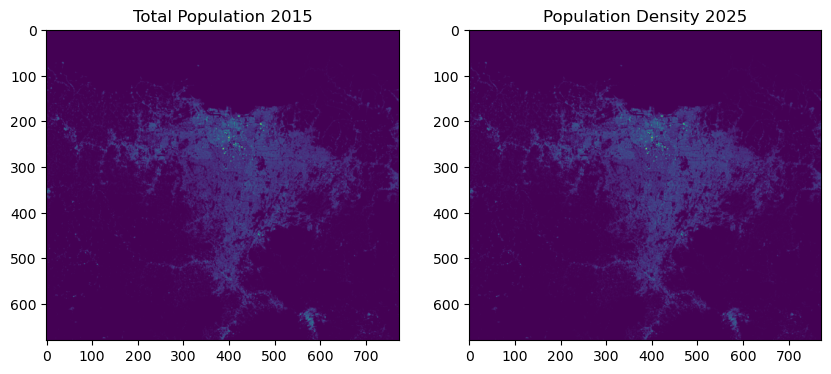

Min and max population in 2015: 0.0, 896.15771484375
Min and max population in 2025: 0.0, 993.8853759765625


In [20]:
# import the absolute population rasters for the early and late calibration years
pop_early_raster =  case_city + f'_POP_population_{calibration_years[0]}_GHSL_150m.tif'
pop_late_raster =  case_city + f'_POP_population_{calibration_years[1]}_GHSL_150m.tif'

pop_early_raster_path = interim_path / pop_early_raster
pop_late_raster_path = interim_path / pop_late_raster
with rasterio.open(pop_early_raster_path, 'r') as src:
    pop_early = src.read(1) # read the first band
    pop_early_meta = src.meta
with rasterio.open(pop_late_raster_path, 'r') as src:
    pop_late = src.read(1) # read the first band
    pop_late_meta = src.meta
# plot the population density rasters for the early and late calibration years side by side
plot_ras_ras(pop_early, pop_late, title1=f'Total Population {calibration_years[0]}', title2=f'Population Density {calibration_years[1]}', AOI_gdf = AOI_gdf)
print(f'Min and max population in {calibration_years[0]}: {pop_early.min()}, {pop_early.max()}')
print(f'Min and max population in {calibration_years[1]}: {pop_late.min()}, {pop_late.max()}')

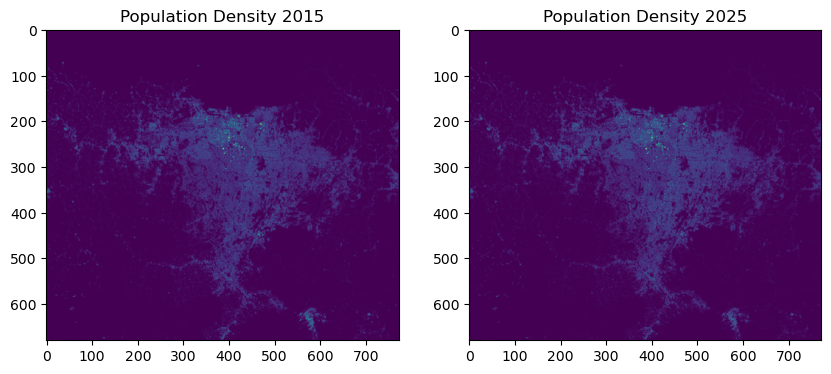

Min and max population density in 2015: 0.0, 0.9457520246505737
Min and max population density in 2025: 0.0, 0.9589040279388428


In [21]:
# import the population density rasters for the early and late calibration years
pop_density_early_raster =  case_city + f'_POP_density_normal_{calibration_years[0]}_GHSL_150m.tif'
pop_density_late_raster =  case_city + f'_POP_density_normal_{calibration_years[1]}_GHSL_150m.tif'

pop_density_early_raster_path = interim_path / pop_density_early_raster
pop_density_late_raster_path = interim_path / pop_density_late_raster
with rasterio.open(pop_density_early_raster_path, 'r') as src:
    pop_density_early = src.read(1) # read the first band
    pop_density_early_meta = src.meta
with rasterio.open(pop_density_late_raster_path, 'r') as src:
    pop_density_late = src.read(1) # read the first band
    pop_density_late_meta = src.meta
# plot the population density rasters for the early and late calibration years side by side
plot_ras_ras(pop_density_early, pop_density_late, title1=f'Population Density {calibration_years[0]}', title2=f'Population Density {calibration_years[1]}', AOI_gdf = AOI_gdf)
print(f'Min and max population density in {calibration_years[0]}: {pop_density_early.min()}, {pop_density_early.max()}')
print(f'Min and max population density in {calibration_years[1]}: {pop_density_late.min()}, {pop_density_late.max()}')

## 1.4 Urbanisation

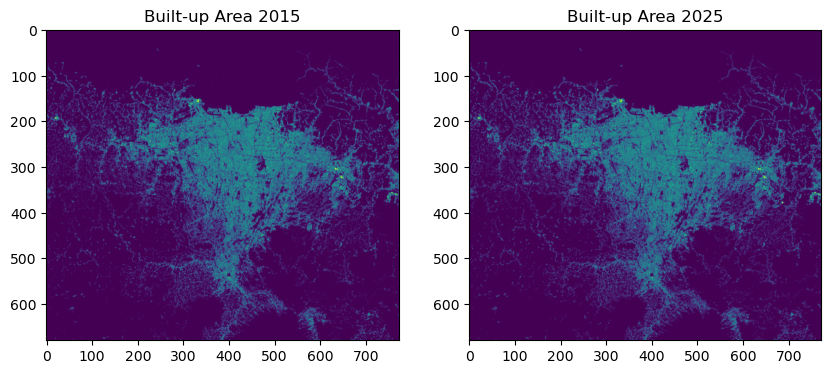

Min and max built-up area in 2015: 1, 8214
Min and max built-up area in 2025: 1, 8214


In [22]:
# import the population density rasters for the early and late calibration years
# sample file name JAK_URB_urban_surface_2025_GHSL_150m
builtup_early_raster =  case_city + f'_URB_urban_surface_{calibration_years[0]}_GHSL_150m.tif'
builtup_late_raster =  case_city + f'_URB_urban_surface_{calibration_years[1]}_GHSL_150m.tif'

builtup_early_raster_path = interim_path / builtup_early_raster
builtup_late_raster_path = interim_path / builtup_late_raster
with rasterio.open(builtup_early_raster_path, 'r') as src:
    builtup_early = src.read(1) # read the first band
    builtup_early_meta = src.meta
with rasterio.open(builtup_late_raster_path, 'r') as src:
    builtup_late = src.read(1) # read the first band
    builtup_late_meta = src.meta
# plot the built-up area rasters for the early and late calibration years side by side
plot_ras_ras(builtup_early, builtup_late, title1=f'Built-up Area {calibration_years[0]}', title2=f'Built-up Area {calibration_years[1]}', AOI_gdf = AOI_gdf)
print(f'Min and max built-up area in {calibration_years[0]}: {builtup_early.min()}, {builtup_early.max()}')
print(f'Min and max built-up area in {calibration_years[1]}: {builtup_late.min()}, {builtup_late.max()}')

# 2. Calculate key population distribution indicators

## 2.1 Calculate base stats at the calibration admin level
1. Import OCHA Admin level 3 units (which will be the calibration spatial units)
2. Calculate zonal statistics for population, population density, built up surface, and GDP for each areal unit
   

ps: Daysimetric mapping:
Performin daysimetric mapping, as suggested in https://gis.stackexchange.com/questions/141763/after-turning-census-block-data-into-a-raster-how-do-i-redistribute-the-density
1. Create a density grid for the Census data by dividing each polygon's count by its area and converting that directly to raster format.
2. Create a relative density grid for the land cover data by joining the relative density table to the land cover type identifier.
3. Multiply the two grids (1) and (2).
4. Compute a zonal sum of the product in (3), using the Census regions as zones. Store this as a raster rather than a table.
5. Multiply (3) by the Census counts, divide by (4), and divide by the cell area.

Index(['ADM2_BA', 'Shape_Area', 'Shape_Leng', 'geometry'], dtype='str')


<Axes: >

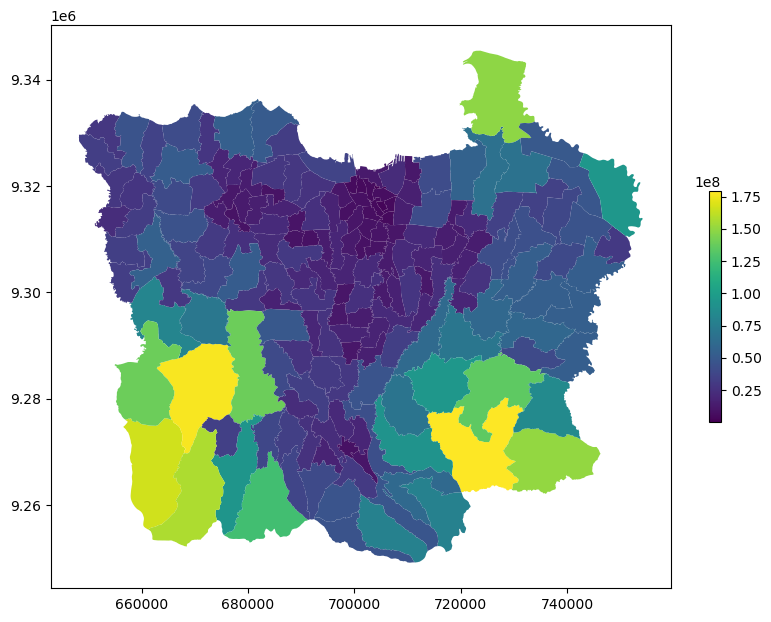

In [19]:
if 'admin3_gdf' not in globals() or admin3_gdf is None:
    try:
        print('importing admin3 shapefile')
        file_name = case_city + '_LIM_admin_boundaries_lvl3_OCHA_2025_A.shp'
        col_list = ['ADM3_EN', 'ADM2_EN', 'ADM3_PCODE', 'Shape_Leng', 'Shape_Area', 'geometry']
        dtype_dict = {'ADM3_EN': str, 'ADM3_PCODE': str, 'Shape_Leng': float, 'Shape_Area': float, 'geometry': 'geometry'}
        admin3_gdf = gpd.read_file(external_path / file_name, columns=col_list, dtype=dtype_dict)
        admin3_gdf = admin3_gdf.rename(columns={'ADM2_EN': 'ADM2_BA'})

        if 'hdi_df_estimated' in globals():
            index_list = hdi_df_estimated['ADM2_BA'].tolist()
            admin3_gdf = admin3_gdf[admin3_gdf.ADM2_BA.isin(index_list)]
        else:
            print('Warning: hdi_df_estimated not defined, admin3_gdf was imported without filtering.')
    except Exception as e:
        print(f'Error importing admin 3 shapefile: {e}')

print(admin3_gdf.columns)
admin3_gdf.plot('Shape_Area', figsize=(10, 10), legend=True, cmap='viridis', legend_kwds={'shrink': 0.3})

<Axes: >

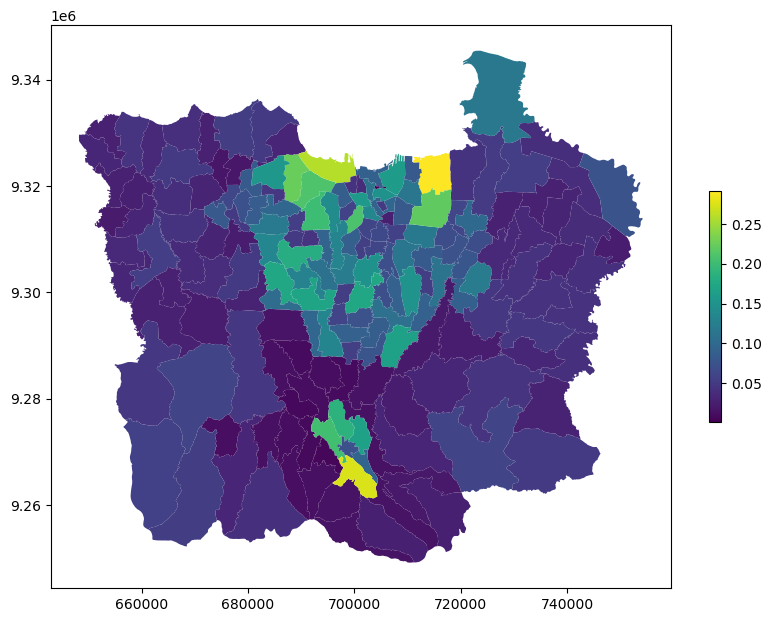

In [20]:
# calculate the proportion of the area of each admin 3 unit to the total area of the corresponding admin 2 unit
admin3_gdf['area_proportion'] = admin3_gdf.apply(lambda row: row['Shape_Area'] / admin2_gdf.loc[row.ADM2_BA, 'Shape_Area'] if row.ADM2_BA in admin2_gdf.index else np.nan, axis=1)
admin3_gdf.plot('area_proportion', figsize=(10, 10), legend=True, cmap='viridis', legend_kwds={'shrink': 0.3})

### GDP

In [21]:
%%time
# Using zonal stats, calculate the mean population density and the total population for each admin 3 unit based on the population density and total population rasters for the early and late calibration years.

'''
pop_density_early
pop_density_late
pop_early
pop_late
builtup_early
builtup_late
gdp_early
gdp_late
admin3_gdf
'''

col_early_name = f'gdp_{calibration_years[0]}'
col_late_name = f'gdp_{calibration_years[1]}'
array_early = gdp_early
array_early_meta = gdp_early_meta
array_late = gdp_late
array_late_meta = gdp_late_meta

admin3_gdf[col_early_name] = rasterstats.zonal_stats(admin3_gdf, array_early, affine=array_early_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
admin3_gdf[col_early_name] = admin3_gdf[col_early_name].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)
admin3_gdf[col_late_name] = rasterstats.zonal_stats(admin3_gdf, array_late, affine=array_late_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
admin3_gdf[col_late_name] = admin3_gdf[col_late_name].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)

CPU times: total: 609 ms
Wall time: 611 ms


### Total Population

In [22]:
# 
col_early_name = f'mean_pop_density_{calibration_years[0]}'
col_late_name = f'mean_pop_density_{calibration_years[1]}'
array_early = pop_density_early
array_early_meta = pop_density_early_meta
array_late = pop_density_late
array_late_meta = pop_density_late_meta

admin3_gdf[col_early_name] = rasterstats.zonal_stats(admin3_gdf, array_early, affine=array_early_meta['transform'], stats=['mean'], nodata=np.nan, geojson_out=False, raster_out=False)
admin3_gdf[col_early_name] = admin3_gdf[col_early_name].apply(lambda x: x['mean'] if isinstance(x, dict) else np.nan)
admin3_gdf[col_late_name] = rasterstats.zonal_stats(admin3_gdf, array_late, affine=array_late_meta['transform'], stats=['mean'], nodata=np.nan, geojson_out=False, raster_out=False)
admin3_gdf[col_late_name] = admin3_gdf[col_late_name].apply(lambda x: x['mean'] if isinstance(x, dict) else np.nan)


### Population Density

In [28]:
# generating stats for the total population rasters for the early and late calibration years
#%%time
col_early_name = f'pop_{calibration_years[0]}'
col_late_name = f'pop_{calibration_years[1]}'
array_early = pop_early
array_early_meta = pop_early_meta
array_late = pop_late
array_late_meta = pop_late_meta

admin3_gdf[col_early_name] = rasterstats.zonal_stats(admin3_gdf, array_early, affine=array_early_meta['transform'], stats=['sum'], nodata=np.nan, geojson_out=False, raster_out=False)
admin3_gdf[col_early_name] = admin3_gdf[col_early_name].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)
admin3_gdf[col_late_name] = rasterstats.zonal_stats(admin3_gdf, array_late, affine=array_late_meta['transform'], stats=['sum'], nodata=np.nan, geojson_out=False, raster_out=False)
admin3_gdf[col_late_name] = admin3_gdf[col_late_name].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)

### Built up

In [29]:
# generating stats for the built-up area rasters for the early and late calibration years
#%%time
col_early_name = f'builtup_{calibration_years[0]}'
col_early_density_name = f'builtup_density_{calibration_years[0]}'
col_late_name = f'builtup_{calibration_years[1]}'
col_late_density_name = f'builtup_density_{calibration_years[1]}'
array_early = builtup_early
array_early_meta = builtup_early_meta
array_late = builtup_late
array_late_meta = builtup_late_meta

admin3_gdf[col_early_name] = rasterstats.zonal_stats(admin3_gdf, array_early, affine=array_early_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
admin3_gdf[col_early_name] = admin3_gdf[col_early_name].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)
admin3_gdf[col_early_density_name] = admin3_gdf.apply(lambda row: row[col_early_name] / row['Shape_Area'] if pd.notna(row[col_early_name]) and row['Shape_Area'] > 0 else np.nan, axis=1)
admin3_gdf[col_late_name] = rasterstats.zonal_stats(admin3_gdf, array_late, affine=array_late_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
admin3_gdf[col_late_name] = admin3_gdf[col_late_name].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)
admin3_gdf[col_late_density_name] = admin3_gdf.apply(lambda row: row[col_late_name] / row['Shape_Area'] if pd.notna(row[col_late_name]) and row['Shape_Area'] > 0 else np.nan, axis=1)

Text(0.5, 1.0, 'Built-Up Density 2025')

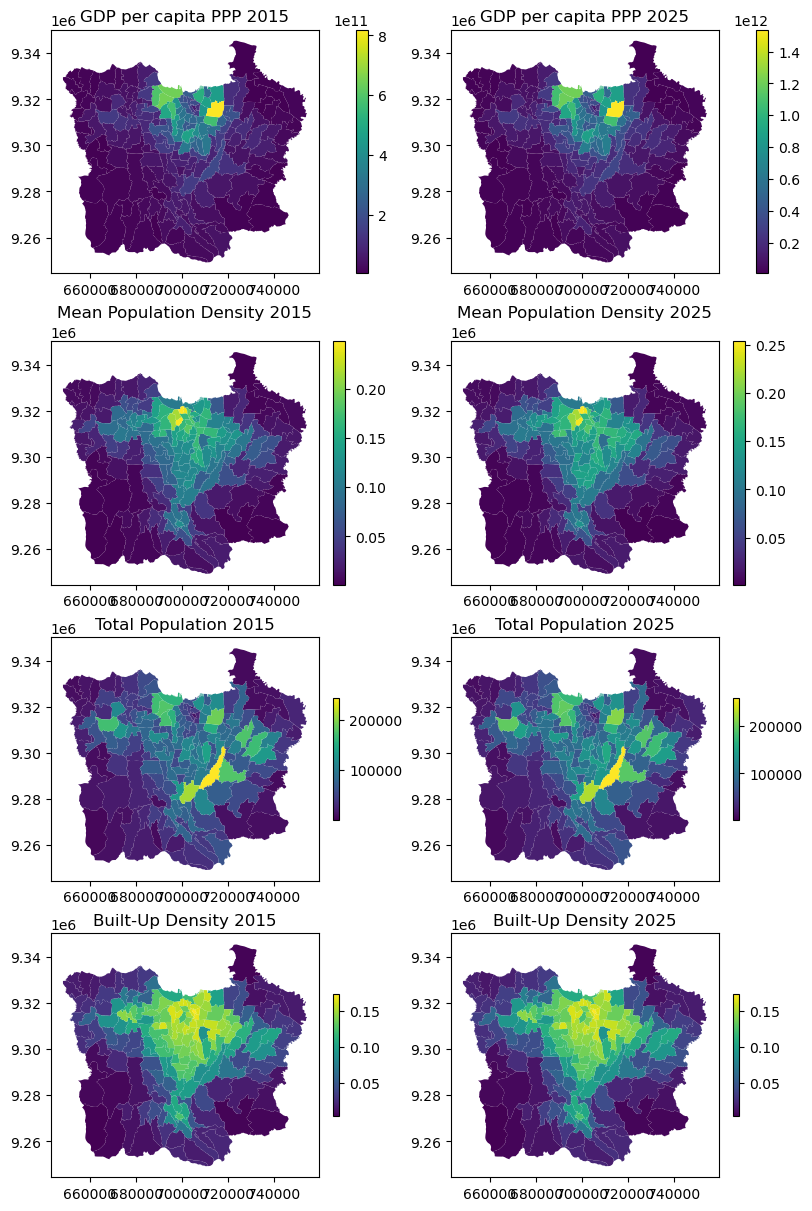

In [30]:
fig, axes = plt.subplots(4, 2, figsize=(8, 12), constrained_layout=True)

# GDP
admin3_gdf.plot(column=f'gdp_{calibration_years[0]}', ax=axes[0,0],legend=True, cmap='viridis') #, legend_kwds={'shrink': 0.5}
axes[0,0].set_title(f'GDP per capita PPP {calibration_years[0]}')
admin3_gdf.plot(column=f'gdp_{calibration_years[1]}', ax=axes[0,1],legend=True, cmap='viridis') #, legend_kwds={'shrink': 0.5}
axes[0,1].set_title(f'GDP per capita PPP {calibration_years[1]}')

# density
admin3_gdf.plot(column=f'mean_pop_density_{calibration_years[0]}', ax=axes[1,0],legend=True, cmap='viridis') #, legend_kwds={'shrink': 0.5}
axes[1,0].set_title(f'Mean Population Density {calibration_years[0]}')
admin3_gdf.plot(column=f'mean_pop_density_{calibration_years[1]}', ax=axes[1,1],legend=True, cmap='viridis') #, legend_kwds={'shrink': 0.5}
axes[1,1].set_title(f'Mean Population Density {calibration_years[1]}')

# population total
admin3_gdf.plot(column=f'pop_{calibration_years[0]}', ax=axes[2,0],legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
axes[2,0].set_title(f'Total Population {calibration_years[0]}')
admin3_gdf.plot(column=f'pop_{calibration_years[1]}', ax=axes[2,1], legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
axes[2,1].set_title(f'Total Population {calibration_years[1]}')

# built up
#admin3_gdf.plot(column=f'builtup_{calibration_years[0]}', ax=axes[3,0],legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
admin3_gdf.plot(column=f'builtup_density_{calibration_years[0]}', ax=axes[3,0],legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
axes[3,0].set_title(f'Built-Up Density {calibration_years[0]}')
admin3_gdf.plot(column=f'builtup_density_{calibration_years[1]}', ax=axes[3,1], legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
axes[3,1].set_title(f'Built-Up Density {calibration_years[1]}')


#plot_ras_ras(array_early, array_late, title1=f'Population Density {calibration_years[0]}', title2=f'Population Density {calibration_years[1]}', AOI_gdf = AOI_gdf)
#admin3_gdf.plot(col_early_name, figsize=(10, 10), legend=True, cmap='viridis')

### export intermediary results

In [31]:
# export the gadm level 3 geopackage
output_geopackage = interim_path / (case_city + '_POP_calibration_metrics_admlvl3.gpkg')
admin3_gdf.to_file(output_geopackage, driver='GPKG')
print(f'GADM level 3 geopackage with population and GDP metrics exported to {output_geopackage}')

GADM level 3 geopackage with population and GDP metrics exported to C:\Sciebo\05_GIS\JAK\interim\JAK_POP_calibration_metrics_admlvl3.gpkg


In [27]:
# export the gadm level 3 to an excel file 
output_excel = interim_path / (case_city + '_POP_calibration_metrics_admlvl3.xlsx')
admin3_gdf.drop(columns='geometry').to_excel(output_excel, index=False)
print(f'GADM level 3 excel file with population and GDP metrics exported to {output_excel}')

GADM level 3 excel file with population and GDP metrics exported to C:\Sciebo\05_GIS\JAK\interim\JAK_POP_calibration_metrics_admlvl3.xlsx


# 3. Estimate the population under each SEP w/ using dasymetric mapping for the admin level 3
1. Load HDI at the municipality/regency scale for admin level 2
1. Downscale the HDI levels into the admin 3 level, with the following co-variates:
   1. GDP per capita (Kummu et al. 2023), already implies nighttime light data and built density
   2. Population GHSL 
   3. [future] LCZ classification, reclassified to meet the assumed probability of each SEP level to be within them

Using the [**tobler package**](https://pysal.org/notebooks/model/tobler/intro.html)


Index(['ADM2_BA', 'ADM2_EN', 'ADM2CODE', 'HDI2025', 'HDI2020', 'HDI2015',
       'LEB2025', 'EYE2025', 'AEP2025', 'LEB2020', 'EYE2020', 'AEP2020',
       'LEB2015', 'EYE2015', 'AEP2015', 'Shape_Leng', 'Shape_Area', 'Notes',
       'geometry'],
      dtype='object')


<Axes: >

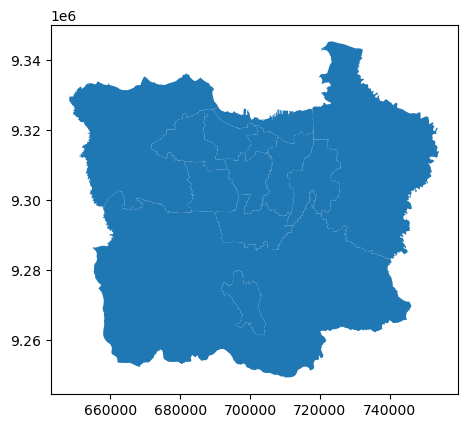

In [24]:
admin2_gdf = gpd.read_file(interim_path / (case_city + '_POP_HDI_component_estimates_ADMlvl2_A.shp'), dtype={'ADM2_BA': str, 'EYE2015': 'float64', 'EYE2020': 'float64',
                                       'EYE2025': 'float64', 'LEB2015': 'float64', 'LEB2020': 'float64',
                                       'LEB2025': 'float64', 'AEP2015': 'float64', 'AEP2020': 'float64', 'AEP2025': 'float64', 'Notes': str}, 
                                       usecols=['ADM2_BA', 'HDI2015','HDI2024','EYE2015', 'LEB2015', 'AEP2015', 'EYE2024', 'LEB2024', 'AEP2024', 'Notes', 'geometry'])
# rename the admin2_gdf columns with 2024 to 2025 to match the admin3_gdf columns
admin2_gdf = admin2_gdf.rename(columns={'EYE2024': 'EYE2025', 'LEB2024': 'LEB2025', 'AEP2024': 'AEP2025', 'HDI2024': 'HDI2025'})
print(admin2_gdf.columns)
admin2_gdf.plot()

### import component weights rasters

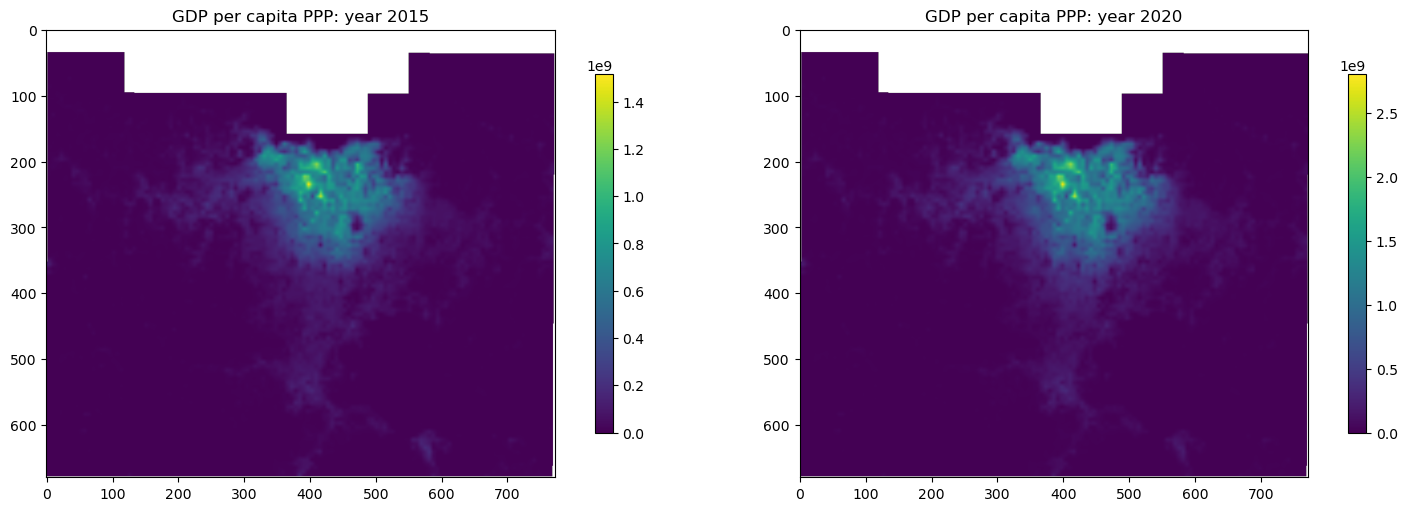

In [25]:
# load the pre-calculated distance to OSM schools and health facilities rasters for the AOI
education_raster_path = interim_path / (case_city + '_LOC_schools_OSM_2025_distance_normal_150m.tif')
with rasterio.open(education_raster_path, 'r') as src:
    education_distance_normal = src.read(1) 
    education_meta = src.meta
health_raster_path = interim_path / (case_city + '_LOC_health_OSM_2025_distance_normal_150m.tif')
with rasterio.open(health_raster_path, 'r') as src:
    health_distance_normal = src.read(1) 
    health_meta = src.meta
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
im = axes[0].imshow(gdp_early.squeeze(), cmap='viridis')
axes[0].set_title(f'GDP per capita PPP: year 2015')
fig.colorbar(im, ax=axes[0], shrink=0.8)
im = axes[1].imshow(gdp_late.squeeze(), cmap='viridis')
axes[1].set_title(f'GDP per capita PPP: year 2020')
fig.colorbar(im, ax=axes[1], shrink=0.8)
plt.show()

In [26]:
print(type(gdp_late.squeeze()), gdp_late.shape, gdp_late.min(), gdp_late.max())

<class 'numpy.ndarray'> (680, 772) nan nan


In [30]:
from tobler.dasymetric import masked_area_interpolate
#JAK_URB_urbanisation_2025_GHSL_150m
builtup_early_raster =  case_city + f'_URB_urbanisation_{calibration_years[0]}_GHSL_150m.tif'
builtup_late_raster =  case_city + f'_URB_urbanisation_{calibration_years[1]}_GHSL_150m.tif'
intensive_variables = [f'mean_pop_density_{calibration_years[0]}', f'mean_pop_density_{calibration_years[1]}',
                      f'builtup_density_{calibration_years[0]}', f'builtup_density_{calibration_years[1]}',
                      f'gdp_{calibration_years[0]}', f'gdp_{calibration_years[1]}']
extensive_variables = [f'pop_{calibration_years[0]}', f'pop_{calibration_years[1]}',
                      f'builtup_{calibration_years[0]}', f'builtup_{calibration_years[1]}']
LEB_early_wt = health_distance_normal
LEB_late_wt = health_distance_normal
EYE_early_wt = education_distance_normal
EYE_late_wt = education_distance_normal
AEP_early_clip = np.where(gdp_early.squeeze() < 0, 0, gdp_early.squeeze())  # replace negative values with 0
#AEP2015_clip = np.where(AEP2015_clip > 1443291648, 1443291648, AEP2015_clip)  # replace values exceeding the threshold
AEP_early_clip = np.where(np.isnan(AEP_early_clip), 0, AEP_early_clip)
AEP_late_clip = np.where(gdp_late.squeeze() < 0, 0, gdp_late.squeeze())  # replace negative values with 0
#AEP2025_clip = np.where(AEP2025_clip > 2668012544, 2668012544, AEP2025_clip)  # replace values exceeding the threshold
AEP_late_clip = np.where(np.isnan(AEP_late_clip), 0, AEP_late_clip)

AEP_early_wt = (AEP_early_clip - np.nanmin(AEP_early_clip)) / (np.nanmax(AEP_early_clip) - np.nanmin(AEP_early_clip))
AEP_late_wt = (AEP_late_clip - np.nanmin(AEP_late_clip)) / (np.nanmax(AEP_late_clip) - np.nanmin(AEP_late_clip))
print('health wt min and max:', health_distance_normal.min(), health_distance_normal.max())
print('education wt min and max:', education_distance_normal.min(), education_distance_normal.max())
print(f'AEP{calibration_years[0]} wt min and max:', AEP_early_wt.min(), AEP_early_wt.max())
print(f'AEP{calibration_years[1]} wt min and max:', AEP_late_wt.min(), AEP_late_wt.max())

health wt min and max: 0.0 1.0
education wt min and max: 0.0 1.0
AEP2015 wt min and max: 0.0 1.0
AEP2025 wt min and max: 0.0 1.0


Min value: 0.0 , Max value: 1.0


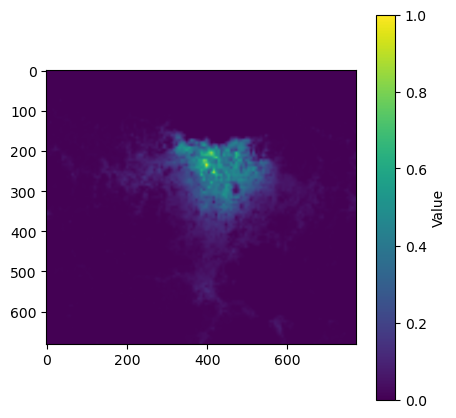

In [28]:
plot_continuous_raster(AEP_late_wt)

### perform interpolation, if needed

#### convert to points

In [ ]:
# convert the GADM level 3 geodataframe to point features
admin3_points_gdf = admin3_gdf.copy()
admin3_points_gdf['geometry'] = admin3_points_gdf['geometry'].centroid

# spatial join the admin3_points_gdf with the admin2_gdf to get the HDI component estimates for each admin 3 unit based on the corresponding admin 2 unit
admin3_points_gdf = admin3_points_gdf.sjoin(admin2_gdf[['ADM2_BA', 'EYE2015', 'LEB2015', 'AEP2015', 'EYE2025', 'LEB2025', 'AEP2025', 'geometry']], how='left', predicate='within')
print(admin3_points_gdf.columns)
print(admin3_points_gdf.loc[:,['ADM2_BA_left', 'ADM2_BA_right']])

# export the point features to a new shapefile
output_shapefile_points = interim_path / (case_city + '_POP_HDI_component_estimates_admlvl3_P.shp')

admin3_points_gdf.to_file(output_shapefile_points)
print(f'GADM level 3 point shapefile with HDI component estimates exported to {output_shapefile_points}')

Index(['ADM2_BA_left', 'Shape_Area', 'Shape_Leng', 'geometry',
       'area_proportion', 'gdp_2015', 'gdp_2025', 'mean_pop_density_2015',
       'mean_pop_density_2025', 'pop_2015', 'pop_2025', 'builtup_2015',
       'builtup_density_2015', 'builtup_2025', 'builtup_density_2025',
       'index_right', 'ADM2_BA_right', 'EYE2015', 'LEB2015', 'AEP2015',
       'EYE2025', 'LEB2025', 'AEP2025'],
      dtype='object')
           ADM2_BA_left       ADM2_BA_right
1                 Bogor               Bogor
2    Kota Jakarta Utara  Kota Jakarta Utara
3                Bekasi              Bekasi
4        Kota Tangerang      Kota Tangerang
6        Kota Tangerang      Kota Tangerang
..                  ...                 ...
253               Bogor               Bogor
254          Kota Bogor          Kota Bogor
255           Tangerang           Tangerang
256  Kota Jakarta Pusat  Kota Jakarta Pusat
257           Tangerang           Tangerang

[185 rows x 2 columns]
GADM level 3 point shapefile wit

#### interpolate

APS 04.05.2026: The code below is not yet working. I used ArcGIS instead.
Also, see [ArcGIS Geographic Weighted Regression](https://pro.arcgis.com/en/pro-app/3.4/tool-reference/spatial-statistics/geographicallyweightedregression.htm)

Min value: nan , Max value: nan


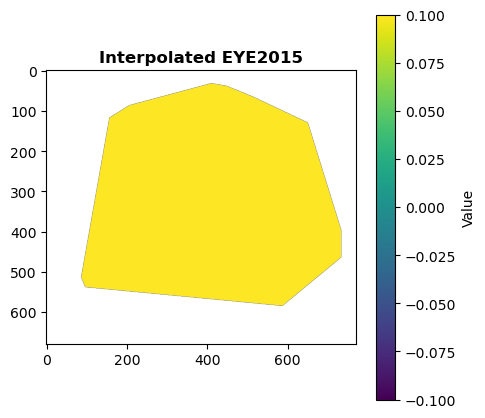

In [ ]:
# interpolate the HDI component estimates in admin3_points_gdf for each year in a raster
ref_raster = ref_raster_150_path

from rasterio.transform import from_origin
from scipy.interpolate import griddata

# Load your ADM3 points with HDI components
adm3_points = admin3_points_gdf.copy() 
component = "EYE2015"  # Example for one HDI component (e.g., education index)

# Extract coordinates and values
values = adm3_points[component].values
x = adm3_points.geometry.x.values
y = adm3_points.geometry.y.values

# Define the grid for interpolation (adjust resolution as needed)
x_min, y_min, x_max, y_max = AOI_gdf.total_bounds
resolution = 150  # Match the resolution of your reference raster
x_grid = np.arange(x_min, x_max, resolution)
y_grid = np.arange(y_min, y_max, resolution)
xx, yy = np.meshgrid(x_grid, y_grid)

#grid_z0 = griddata(points, values, (grid_x, grid_y), method='nearest')
#grid_z1 = griddata(points, values, (grid_x, grid_y), method='linear')
#grid_z2 = griddata(points, values, (grid_x, grid_y), method='cubic')

# Perform IDW interpolation
# Note: `griddata` can handle NaN values and extrapolates to the grid extent
interpolated_values = griddata(
    (x, y), values, (xx, yy),
    method='linear',  # or 'nearest' or 'cubic'
    fill_value=np.nan  # Fill NaN for areas outside the convex hull
)
plot_continuous_raster(interpolated_values, title=f'Interpolated {component}')
save_file = False

if save_file:
    # Save the interpolated raster to a GeoTIFF
    transform = from_origin(x_min, y_max, resolution, resolution)
    with rasterio.open(
        f"{component}_raster.tif", 'w',
        driver='GTiff',
        height=interpolated_values.shape[0],
        width=interpolated_values.shape[1],
        count=1,
        dtype=interpolated_values.dtype,
        crs=adm3_points.crs,
        transform=transform,
    ) as dst:
        dst.write(interpolated_values, 1)

### import interpolated rasters if they exist

In [31]:
# import the externally interpolated rasters
raster_name_dict = {
    'EYE_early': case_city + f'_POP_HDI_EYE{calibration_years[0]}_IDW_150m.tif',
    'LEB_early': case_city + f'_POP_HDI_LEB{calibration_years[0]}_IDW_150m.tif',
    'AEP_early': case_city + f'_POP_HDI_AEP{calibration_years[0]}_IDW_150m.tif',
    'EYE_late': case_city + f'_POP_HDI_EYE{calibration_years[1]}_IDW_150m.tif',
    'LEB_late': case_city + f'_POP_HDI_LEB{calibration_years[1]}_IDW_150m.tif',
    'AEP_late': case_city + f'_POP_HDI_AEP{calibration_years[1]}_IDW_150m.tif'
}

interpolated_rasters = {}
# reproject and align the rasters to the reference raster if needed, and check the shape and data type of the loaded rasters
for component, raster_name in raster_name_dict.items():
    source_raster_path = external_path / raster_name
    destination_raster_path = interim_path / raster_name
    reproj_match(source_raster_path, ref_raster_path, destination_raster_path, resampling=Resampling.cubic)

Coregistered to shape: 680 772 
 Affine | 150.00, 0.00, 639000.00|
| 0.00,-150.00, 9351000.00|
| 0.00, 0.00, 1.00|
Coregistered to shape: 680 772 
 Affine | 150.00, 0.00, 639000.00|
| 0.00,-150.00, 9351000.00|
| 0.00, 0.00, 1.00|
Coregistered to shape: 680 772 
 Affine | 150.00, 0.00, 639000.00|
| 0.00,-150.00, 9351000.00|
| 0.00, 0.00, 1.00|
Coregistered to shape: 680 772 
 Affine | 150.00, 0.00, 639000.00|
| 0.00,-150.00, 9351000.00|
| 0.00, 0.00, 1.00|
Coregistered to shape: 680 772 
 Affine | 150.00, 0.00, 639000.00|
| 0.00,-150.00, 9351000.00|
| 0.00, 0.00, 1.00|
Coregistered to shape: 680 772 
 Affine | 150.00, 0.00, 639000.00|
| 0.00,-150.00, 9351000.00|
| 0.00, 0.00, 1.00|


In [32]:
for component, raster_name in raster_name_dict.items():
    raster_path = interim_path / raster_name
    with rasterio.open(raster_path, 'r') as src:
        interpolated_rasters[component] = src.read(1)  # Read the first band
        print(f'Loaded raster for {component} with shape {interpolated_rasters[component].shape} and dtype {interpolated_rasters[component].dtype}')


Loaded raster for EYE_early with shape (680, 772) and dtype float32
Loaded raster for LEB_early with shape (680, 772) and dtype float32
Loaded raster for AEP_early with shape (680, 772) and dtype float32
Loaded raster for EYE_late with shape (680, 772) and dtype float32
Loaded raster for LEB_late with shape (680, 772) and dtype float32
Loaded raster for AEP_late with shape (680, 772) and dtype float32


### multiply the interporlated rasters by the weights

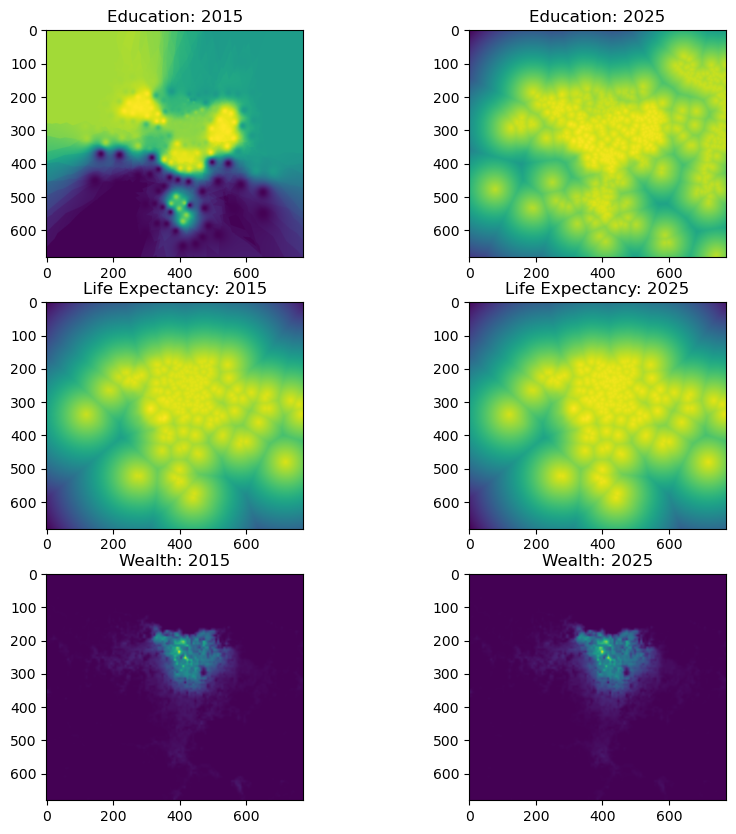

In [33]:


#EYE_early_HDI_ADM3_raster = interpolated_rasters[f'EYE_early'] * (1 - EYE_early_wt)
EYE_early_HDI_ADM3_raster = interpolated_rasters[f'EYE_early']
EYE_early_HDI_ADM3_normal = (EYE_early_HDI_ADM3_raster - np.nanmin(EYE_early_HDI_ADM3_raster)) / (np.nanmax(EYE_early_HDI_ADM3_raster) - np.nanmin(EYE_early_HDI_ADM3_raster))
LEB_early_HDI_ADM3_raster = interpolated_rasters[f'LEB_early'] * (1 -LEB_early_wt)
LEB_early_HDI_ADM3_normal = (LEB_early_HDI_ADM3_raster - np.nanmin(LEB_early_HDI_ADM3_raster)) / (np.nanmax(LEB_early_HDI_ADM3_raster) - np.nanmin(LEB_early_HDI_ADM3_raster))
AEP_early_HDI_ADM3_raster = interpolated_rasters[f'AEP_early'] * AEP_early_wt
AEP_early_HDI_ADM3_normal = (AEP_early_HDI_ADM3_raster - np.nanmin(AEP_early_HDI_ADM3_raster)) / (np.nanmax(AEP_early_HDI_ADM3_raster) - np.nanmin(AEP_early_HDI_ADM3_raster))
#AEP_early_HDI_ADM3_normal = (np.log(AEP_early_HDI_ADM3_raster) - np.log(np.nanmin(AEP_early_HDI_ADM3_raster))) / (np.log(np.nanmax(AEP_early_HDI_ADM3_raster)) - np.log(np.nanmin(AEP_early_HDI_ADM3_raster)))
EYE_late_HDI_ADM3_raster = interpolated_rasters[f'EYE_late'] * (1 -EYE_late_wt)
EYE_late_HDI_ADM3_normal = (EYE_late_HDI_ADM3_raster - np.nanmin(EYE_late_HDI_ADM3_raster)) / (np.nanmax(EYE_late_HDI_ADM3_raster) - np.nanmin(EYE_late_HDI_ADM3_raster))
LEB_late_HDI_ADM3_raster = interpolated_rasters[f'LEB_late'] * (1 -LEB_late_wt)
LEB_late_HDI_ADM3_normal = (LEB_late_HDI_ADM3_raster - np.nanmin(LEB_late_HDI_ADM3_raster)) / (np.nanmax(LEB_late_HDI_ADM3_raster) - np.nanmin(LEB_late_HDI_ADM3_raster))
AEP_late_HDI_ADM3_raster = interpolated_rasters[f'AEP_late'] * AEP_late_wt
AEP_late_HDI_ADM3_normal = (AEP_late_HDI_ADM3_raster - np.nanmin(AEP_late_HDI_ADM3_raster)) / (np.nanmax(AEP_late_HDI_ADM3_raster) - np.nanmin(AEP_late_HDI_ADM3_raster))
#AEP_late_HDI_ADM3_normal = (np.log(AEP_late_HDI_ADM3_raster) - np.log(np.nanmin(AEP_late_HDI_ADM3_raster))) / (np.log(np.nanmax(AEP_late_HDI_ADM3_raster)) - np.log(np.nanmin(AEP_late_HDI_ADM3_raster)))

# calculate the HDI raster for the early and late years using the weighted sum of the component rasters
HDI_early = (EYE_early_HDI_ADM3_normal * LEB_early_HDI_ADM3_normal * AEP_early_HDI_ADM3_normal) ** (1/3)
# 'HDI2025', 'HDI2020', 'HDI2015',
HDI_early_min = admin2_gdf[f'HDI{calibration_years[0]}'].min()
HDI_early_max = admin2_gdf[f'HDI{calibration_years[0]}'].max()
HDI_early_raster_min = np.nanmin(HDI_early)
HDI_early_raster_max = np.nanmax(HDI_early)
HDI_early_raster_den = HDI_early_raster_max - HDI_early_raster_min
if HDI_early_raster_den != 0:
    HDI_early_normal = ((HDI_early - HDI_early_raster_min) / HDI_early_raster_den) * (HDI_early_max - HDI_early_min) + HDI_early_min
else:
    HDI_early_normal = np.full_like(HDI_early, HDI_early_min)
HDI_late = (EYE_late_HDI_ADM3_normal * LEB_late_HDI_ADM3_normal * AEP_late_HDI_ADM3_normal) ** (1/3)
HDI_late_min = admin2_gdf[f'HDI{calibration_years[1]}'].min()
HDI_late_max = admin2_gdf[f'HDI{calibration_years[1]}'].max()
HDI_late_raster_min = np.nanmin(HDI_late)
HDI_late_raster_max = np.nanmax(HDI_late)
HDI_late_raster_den = HDI_late_raster_max - HDI_late_raster_min
if HDI_late_raster_den != 0:
    HDI_late_normal = ((HDI_late - HDI_late_raster_min) / HDI_late_raster_den) * (HDI_late_max - HDI_late_min) + HDI_late_min
else:
    HDI_late_normal = np.full_like(HDI_late, HDI_late_min)

# plot the HDI rasters side by side
#plot_continuous_raster(HDI_early_normal)
#plot_ras_ras(HDI_early, HDI_late)

# plot all the normalised rasters, with early rasters on the left and late rasters on the right
fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
show(EYE_early_HDI_ADM3_normal, ax = ax[0,0])
ax[0,0].set_title(f'Education: {calibration_years[0]}')
show(LEB_early_HDI_ADM3_normal, ax = ax[1,0])
ax[1,0].set_title(f'Life Expectancy: {calibration_years[0]}')
show(AEP_early_HDI_ADM3_normal, ax = ax[2,0])
ax[2,0].set_title(f'Wealth: {calibration_years[0]}')
show(EYE_late_HDI_ADM3_normal, ax = ax[0,1])
ax[0,1].set_title(f'Education: {calibration_years[1]}')
show(LEB_late_HDI_ADM3_normal, ax = ax[1,1])
ax[1,1].set_title(f'Life Expectancy: {calibration_years[1]}')
show(AEP_late_HDI_ADM3_normal, ax = ax[2,1])
ax[2,1].set_title(f'Wealth: {calibration_years[1]}')
plt.show()


In [34]:
# agreggate the HDI rasters at the adm level 3 units using rasterstats
col_early_name = f'HDI_{calibration_years[0]}'
col_late_name = f'HDI_{calibration_years[1]}'
array_early = HDI_early_normal
array_late = HDI_late_normal
array_early_meta = gdp_early_meta
array_late_meta = gdp_late_meta
admin3_gdf[col_early_name] = rasterstats.zonal_stats(admin3_gdf, array_early, affine=array_early_meta['transform'], stats=['mean'], nodata=np.nan, geojson_out=False, raster_out=False)
admin3_gdf[col_early_name] = admin3_gdf[col_early_name].apply(lambda x: x['mean'] if isinstance(x, dict) else np.nan)
admin3_gdf[col_late_name] = rasterstats.zonal_stats(admin3_gdf, array_late, affine=array_late_meta['transform'], stats=['mean'], nodata=np.nan, geojson_out=False, raster_out=False)
admin3_gdf[col_late_name] = admin3_gdf[col_late_name].apply(lambda x: x['mean'] if isinstance(x, dict) else np.nan)

### explore the downscaled HDI levels

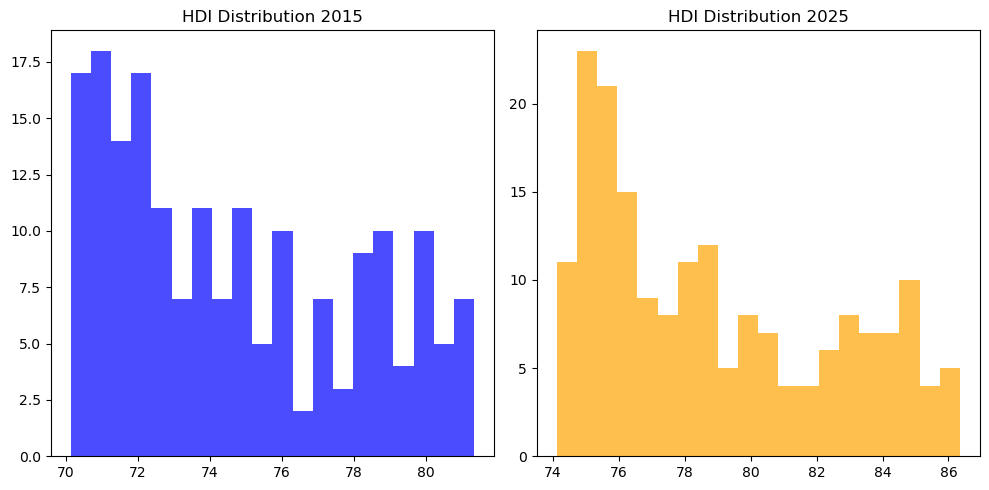

In [35]:
# plot a histogram of the HDI values for the early and late years
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(admin3_gdf[col_early_name].dropna(), bins=20, color='blue', alpha=0.7)
plt.title(f'HDI Distribution {calibration_years[0]}')
plt.subplot(1, 2, 2)
#admin3_gdf.plot(column=col_early_name, figsize=(10, 10), legend=True, cmap='viridis', legend_kwds={'shrink': 0.3})
plt.hist(admin3_gdf[col_late_name].dropna(), bins=20, color='orange', alpha=0.7)
plt.title(f'HDI Distribution {calibration_years[1]}')
plt.tight_layout()
plt.show()

In [36]:
admin3_gdf[col_early_name].describe()

count    185.000000
mean      74.682425
std        3.365397
min       70.140324
25%       71.707824
50%       74.041544
75%       77.724252
max       81.337223
Name: HDI_2015, dtype: float64

In [37]:
admin3_gdf[col_late_name].describe()

count    185.000000
mean      78.894001
std        3.576801
min       74.108405
25%       75.761198
50%       78.071290
75%       82.210029
max       86.345482
Name: HDI_2025, dtype: float64

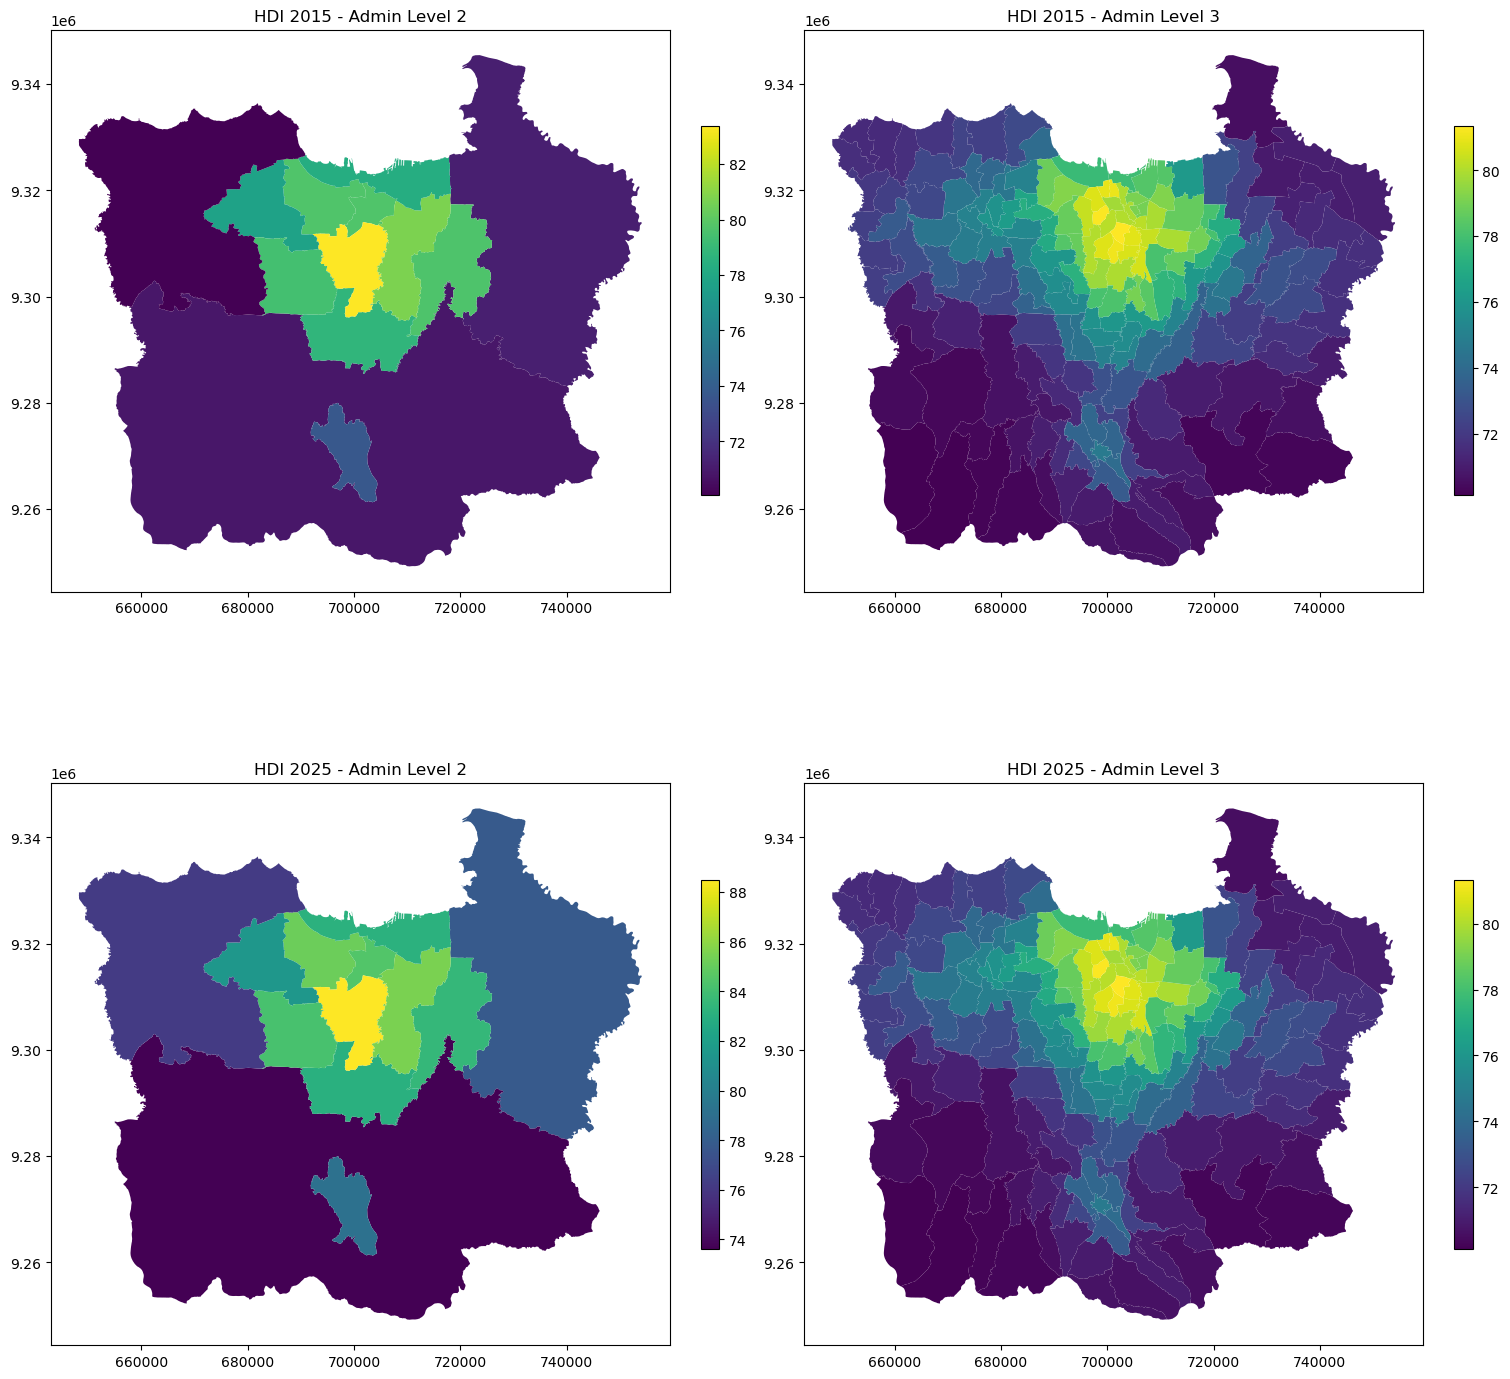

In [38]:
# plot two maps of the  HDI values. On the left column, the map from the admin 2 level, on the right column, the map from the admin 3 level. Do this for both the early and late calibration years.
fig, ax = plt.subplots(2, 2, figsize=(15, 15), constrained_layout=True)
admin2_gdf.plot(column=f'HDI{calibration_years[0]}', ax=ax[0,0], legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
ax[0,0].set_title(f'HDI {calibration_years[0]} - Admin Level 2')
admin3_gdf.plot(column=col_early_name, ax=ax[0,1], legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
ax[0,1].set_title(f'HDI {calibration_years[0]} - Admin Level 3')
admin2_gdf.plot(column=f'HDI{calibration_years[1]}', ax=ax[1,0], legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
ax[1,0].set_title(f'HDI {calibration_years[1]} - Admin Level 2')
admin3_gdf.plot(column=col_early_name, ax=ax[1,1], legend=True, cmap='viridis', legend_kwds={'shrink': 0.5})
ax[1,1].set_title(f'HDI {calibration_years[1]} - Admin Level 3')
plt.show()

### estimate population for the model SEP levels based on HDI

In [39]:
admin3_gdf.head()

,ADM2_BA,Shape_Area,Shape_Leng,geometry,area_proportion,gdp_2015,gdp_2025,mean_pop_density_2015,mean_pop_density_2025,pop_2015,pop_2025,builtup_2015,builtup_density_2015,builtup_2025,builtup_density_2025,HDI_2015,HDI_2025
1,Bogor,2.560295e+07,41764.274838,"POLYGON ((690340.922 9266867.007, 690319.857 9...",0.008553,2.571894e+10,4.398508e+10,0.032796,0.033145,35146.597656,38853.890625,1082539.0,0.042282,1165235.0,0.045512,71.498867,76.195340
2,Kota Jakarta Utara,2.243273e+07,34408.190734,"MULTIPOLYGON (((709230.77 9320652.394, 709230....",0.159932,5.192789e+11,9.813642e+11,0.132819,0.133936,125097.039062,137987.750000,3331842.0,0.148526,3341285.0,0.148947,78.343836,83.498428
3,Bekasi,6.596211e+07,64962.606224,"POLYGON ((726616.911 9317178.419, 726626.763 9...",0.052025,8.873535e+10,1.914075e+11,0.028237,0.029498,78583.031250,89799.656250,2840534.0,0.043063,3077669.0,0.046658,72.311718,76.309856
4,Kota Tangerang,9.849298e+06,18969.492864,"POLYGON ((690314.793 9313251.924, 690314.99 93...",0.054276,9.089121e+10,1.874723e+11,0.144215,0.160850,59716.203125,72855.703125,1271253.0,0.129070,1278800.0,0.129837,77.001144,80.876394
6,Kota Tangerang,8.944131e+06,15279.927726,"POLYGON ((689186.943 9308629.595, 689149.261 9...",0.049288,8.141898e+10,1.708564e+11,0.155334,0.174049,58873.640625,72161.234375,1307687.0,0.146206,1311272.0,0.146607,76.943267,80.859004


In [42]:
print('minimum HDI early:', admin3_gdf.HDI_2015.min(), '\nmaximum HDI early:', admin3_gdf.HDI_2015.max())

minimum HDI early: 70.14032411174396 
maximum HDI early: 81.33722310126582


In [44]:
# Load ADM3 data with HDI and population
adm3 = admin3_gdf
hdi_early_var = f'HDI_{calibration_years[0]}'
hdi_late_var = f'HDI_{calibration_years[1]}'
pop_early_var = f'pop_{calibration_years[0]}'
pop_late_var = f'pop_{calibration_years[1]}'

# Define probability functions
def calculate_sep_probabilities(hdi, hdi_min, hdi_max):
    hdi_normal = (hdi - hdi_min) / (hdi_max - hdi_min)
    p_deprived = np.maximum(0, np.minimum(1, 1 - hdi_normal * 2))
    p_low = np.maximum(0, np.minimum(1, 2 * (0.5 - np.abs(hdi_normal - 0.5))))
    p_medium = np.maximum(0, np.minimum(1, 2 * (hdi_normal - 0.25)))
    p_high = np.maximum(0, np.minimum(1, hdi_normal * 2 - 1))
    total = p_deprived + p_low + p_medium + p_high
    #print(p_deprived, p_low, p_medium, p_high)
    return p_deprived / total, p_low / total, p_medium / total, p_high / total

# Apply to ADM3 units
# probabilitiy variables
p_early_deprived = f'p_deprived_{calibration_years[0]}'
p_early_low = f'p_low_{calibration_years[0]}'
p_early_mid = f'p_medium_{calibration_years[0]}'
p_early_high = f'p_high_{calibration_years[0]}'
p_late_deprived = f'p_deprived_{calibration_years[1]}'
p_late_low = f'p_low_{calibration_years[1]}'  
p_late_mid = f'p_medium_{calibration_years[1]}'
p_late_high = f'p_high_{calibration_years[1]}'

# population variables
pop_early_deprived = f'pop_deprived_{calibration_years[0]}'
pop_early_low = f'pop_low_{calibration_years[0]}'
pop_early_mid = f'pop_medium_{calibration_years[0]}'
pop_early_high = f'pop_high_{calibration_years[0]}'
pop_early_total = f'pop_high_{calibration_years[0]}_total'
pop_early_diff = f'pop_high_{calibration_years[0]}_diff'

pop_late_deprived = f'pop_deprived_{calibration_years[1]}'
pop_late_low = f'pop_low_{calibration_years[1]}'  
pop_late_mid = f'pop_medium_{calibration_years[1]}'
pop_late_high = f'pop_high_{calibration_years[1]}'
pop_late_total = f'pop_high_{calibration_years[1]}_total'
pop_late_diff = f'pop_high_{calibration_years[1]}_diff'

# calculate populations for the early calibration year
adm3[[p_early_deprived, p_early_low, p_early_mid, p_early_high]] = adm3.apply(
    lambda row: calculate_sep_probabilities(row[hdi_early_var], adm3[hdi_early_var].min(),adm3[hdi_early_var].max()),
    axis=1,
    result_type="expand"
)

# calculate populations for the late calibration year
adm3[[p_late_deprived, p_late_low, p_late_mid, p_late_high]] = adm3.apply(
    lambda row: calculate_sep_probabilities(row[hdi_late_var], adm3[hdi_late_var].min(),adm3[hdi_late_var].max()),
    axis=1,
    result_type="expand"
)

# Distribute population
# early calibration year
adm3[pop_early_deprived] = adm3[pop_early_var] * adm3[p_early_deprived]
adm3[pop_early_low] = adm3[pop_early_var] * adm3[p_early_low]
adm3[pop_early_mid] = adm3[pop_early_var] * adm3[p_early_mid]
adm3[pop_early_high] = adm3[pop_early_var] * adm3[p_early_high]
adm3[pop_early_total] = adm3[pop_early_deprived] + adm3[pop_early_low] + adm3[pop_early_mid] + adm3[pop_early_high] 
adm3[pop_early_diff] = adm3[pop_early_var] - adm3[pop_early_total] 

# late calibration year
adm3[pop_late_deprived] = adm3[pop_late_var] * adm3[p_late_deprived]
adm3[pop_late_low] = adm3[pop_late_var] * adm3[p_late_low]
adm3[pop_late_mid] = adm3[pop_late_var] * adm3[p_late_mid]
adm3[pop_late_high] = adm3[pop_late_var] * adm3[p_late_high]
adm3[pop_late_total] = adm3[pop_late_deprived] + adm3[pop_late_low] + adm3[pop_late_mid] + adm3[pop_late_high] 
adm3[pop_late_diff] = adm3[pop_late_var] - adm3[pop_late_total] 

# Save results
savefile = False
if savefile:
    adm3.to_file("adm3_with_sep_distribution.shp")

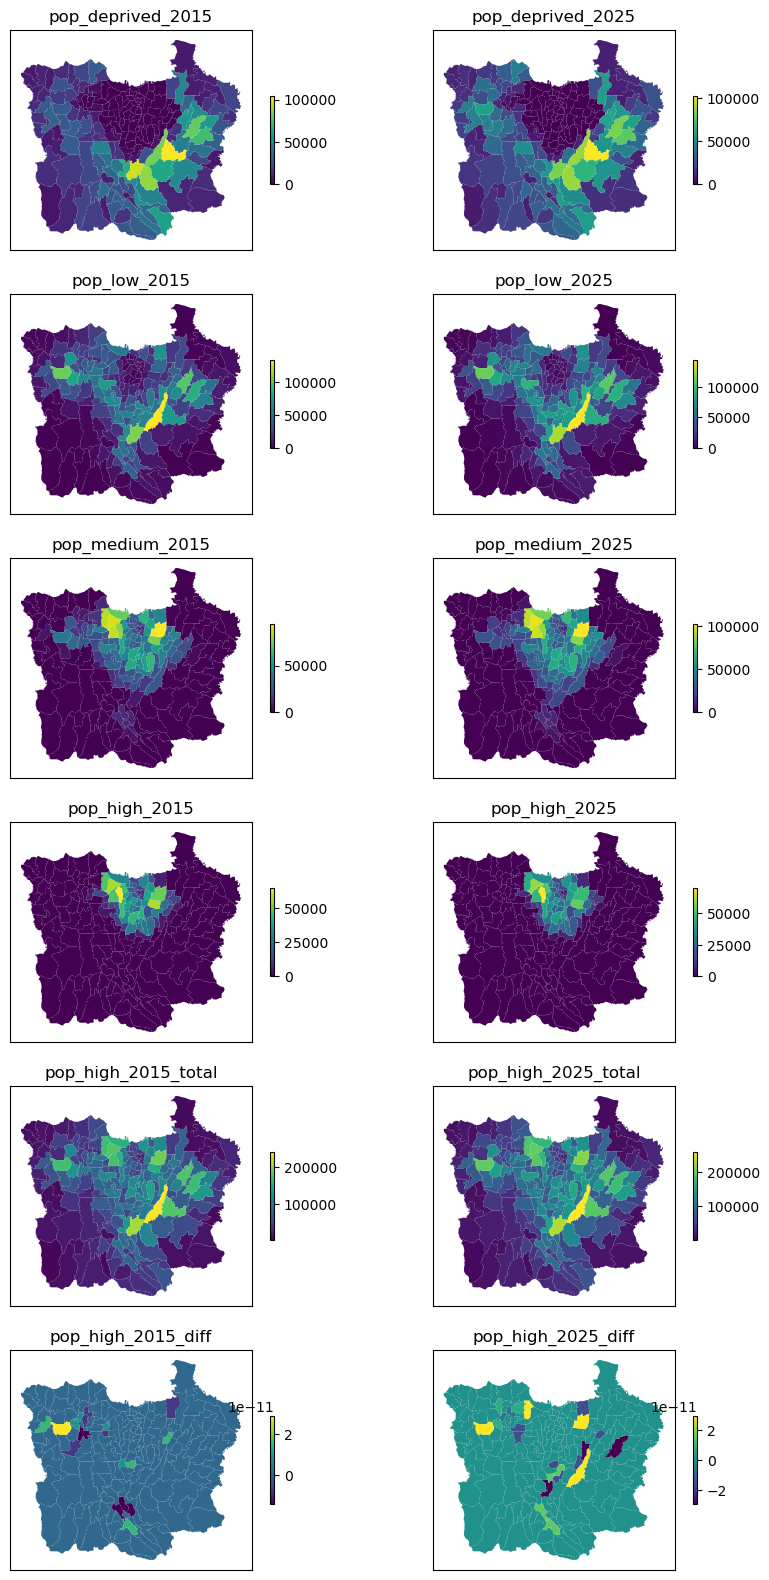

In [45]:
# plot the population distributions
fig, ax = plt.subplots(nrows=6, ncols = 2, figsize=(10,20))
shrink = 0.4
admin3_gdf.plot(column=pop_early_deprived, ax=ax[0,0], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[0,0].set_title(f'{pop_early_deprived}')
admin3_gdf.plot(column=pop_late_deprived, ax=ax[0,1], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[0,1].set_title(f'{pop_late_deprived}')
admin3_gdf.plot(column=pop_early_low, ax=ax[1,0], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})

ax[1,0].set_title(f'{pop_early_low}')
admin3_gdf.plot(column=pop_late_low, ax=ax[1,1], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[1,1].set_title(f'{pop_late_low}')

admin3_gdf.plot(column=pop_early_mid, ax=ax[2,0], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[2,0].set_title(f'{pop_early_mid}')
admin3_gdf.plot(column=pop_late_mid, ax=ax[2,1], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[2,1].set_title(f'{pop_late_mid}')

admin3_gdf.plot(column=pop_early_high, ax=ax[3,0], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[3,0].set_title(f'{pop_early_high}')
admin3_gdf.plot(column=pop_late_high, ax=ax[3,1], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[3,1].set_title(f'{pop_late_high}')

admin3_gdf.plot(column=pop_early_total, ax=ax[4,0], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[4,0].set_title(f'{pop_early_total}')
admin3_gdf.plot(column=pop_late_total, ax=ax[4,1], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[4,1].set_title(f'{pop_late_total}')

admin3_gdf.plot(column=pop_early_diff, ax=ax[5,0], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[5,0].set_title(f'{pop_early_diff}')
admin3_gdf.plot(column=pop_late_diff, ax=ax[5,1], legend=True, cmap='viridis', legend_kwds={'shrink': shrink})
ax[5,1].set_title(f'{pop_late_diff}')
for axs in ax.flat:
    axs.set_xticks([])
    axs.set_yticks([])

plt.show()

### export

In [ ]:
# export the HDI rasters
export_file = True
if export_file:
    try:
        file_name = case_city + f'_POP_HDI_continuous{calibration_years[0]}_150m.tif'
        url = interim_path / file_name
        export_raster(raster = HDI_early.squeeze(),
                    url = url,
                    data_type=rasterio.int16,
                    ref_raster_path=ref_raster_150_path)
        print('Exported file:', url)
    except Exception as e:
        print('Error exporting file:', e)

if export_file:
    try:
        file_name = case_city + f'_POP_HDI_continuous{calibration_years[1]}_150m.tif'
        url = interim_path / file_name
        export_raster(raster = HDI_late.squeeze(),
                    url = url,
                    data_type=rasterio.int16,
                    ref_raster_path=ref_raster_150_path)
        print('Exported file:', url)
    except Exception as e:
        print('Error exporting file:', e)

Exported file: D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\interim\JAK_POP_HDI_continuous2015_150m.tif
Exported file: D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\interim\JAK_POP_HDI_continuous2025_150m.tif


In [46]:
# export the gadm level 3 geopackage with the HDI estimates
output_geopackage = interim_path / (case_city + '_POP_HDI_component_estimates_ADMlvl3_A.gpkg')
admin3_gdf.to_file(output_geopackage, driver='GPKG')

# 4. Preprocess the externally-generated vector grid

In [8]:
export_file = True
grid_gdf = gpd.read_file(interim_path / (case_city + '_LIM_grid_150m_identify_admin_level2_A.shp'), 
                         usecols=['ADM2_BA', 'ADM2_EN', 'ADM2CODE', 'HDI2024', 'HDI2015',
                                  'LEB2024', 'EYE2024', 'AEP2024','LEB2015', 'EYE2015', 'AEP2015', 
                                  'Shape_Area', 'LVL2_AREA', 'LVL2_PROP','geometry'])
#
print(grid_gdf.columns)
#grid_gdf.drop(columns=['Shape_Leng'], inplace=True)
#grid_gdf.rename(columns={'Shape_Area': 'grid_area', 'Shape_Le_1': 'grid_length'}, inplace=True)
grid_gdf.rename(columns={'HDI2024': 'HDI2025', 'LEB2024': 'LEB2025', 'EYE2024': 'EYE2025', 'AEP2024': 'AEP2025'}, inplace=True)
print(grid_gdf.columns)
grid_gdf['LVL2_PROP'] = (grid_gdf['grid_area'] / (grid_gdf['LVL2_AREA'].astype(float))) #results are tiny (~e-08), so no rounding should be applied here

# let's export this revised/cleaned version of the grid
if export_file:
    grid_gdf.to_file(interim_path / (case_city + '_LIM_grid_150m_identify_admin_level2_A.shp'))

Index(['ADM2_BA', 'ADM2_EN', 'ADM2CODE', 'HDI2025', 'HDI2020', 'HDI2015',
       'LEB2025', 'EYE2025', 'AEP2025', 'LEB2020', 'EYE2020', 'AEP2020',
       'LEB2015', 'EYE2015', 'AEP2015', 'Notes', 'LVL2_AREA', 'grid_lengt',
       'grid_area', 'LVL2_PROP', 'geometry'],
      dtype='str')
Index(['ADM2_BA', 'ADM2_EN', 'ADM2CODE', 'HDI2025', 'HDI2020', 'HDI2015',
       'LEB2025', 'EYE2025', 'AEP2025', 'LEB2020', 'EYE2020', 'AEP2020',
       'LEB2015', 'EYE2015', 'AEP2015', 'Notes', 'LVL2_AREA', 'grid_lengt',
       'grid_area', 'LVL2_PROP', 'geometry'],
      dtype='str')


# 5. Import the model calibration results and check calibration accuracy

Parameters to use in calibration:
- Urbanisation rate
- Proportion of SEP
  - Deprived
  - Low
  - Middle 
  - High
Workflow:
1. Load **agent** parameters: utility weight 
2. Load **model** parameters: agent population, slope, and other parameters
3. Save parameters in simulation run file using the 'run_report_template' sheet in "D:\GIT\ti-city-model\docs\TI_model_runs.xlsx"

In [27]:
# import the current model weights value
weights_file_name = 'weights.csv'
weights_path = ti_city_ascii_path / weights_file_name
#print(weights_path)
if weights_path.exists():
    weights_df = pd.read_csv(weights_path)
    print(f'Weights file found. Columns: {weights_df.columns.tolist()}')
weights_df.head()

Weights file found. Columns: ['agent', 'suburban', 'neighbour', 'bu', 'cbd', 'mall', 'markets', 'road', 'density', 'schools', 'attractive', 'health', 'random', 'water']


,agent,suburban,neighbour,bu,cbd,mall,markets,road,density,schools,attractive,health,random,water
0,dp,6,9,4,4,1,7,3,9,4,2,2,1,10
1,li,8,7,4,6,2,7,8,4,4,6,4,1,5
2,mi,6,7,7,7,7,7,6,4,4,7,4,1,5
3,hi,2,7,9,9,6,3,5,8,4,10,3,1,8
4,mi_red,7,0,0,0,0,0,8,0,5,7,0,0,0


In [ ]:
# import the latest results file


# The end (for now).